# Hey Kenny!

Thanks for making the PR. I just reviewed it with solveit (see the bottom of the dialog).

The LLM flagged a couple of issues. Would you please take a look and see what you think is worth fixing?

(this is a bit of an experiment reviewing a PR this way, please let me know if this is useful)

Thanks!
Rens

# App

> The main fasthtml app of solveblog

In [ ]:
#|default_exp app

In [ ]:
import tempfile, sys
from solveblog.core import solveblog_new

In [ ]:
tmp = tempfile.mkdtemp(prefix='solveblog_dev_')

In [ ]:
%cd {tmp}
solveblog_new(name='Test User', 
              port='8000', 
              email='test@test.com',
              description='A test blog', 
              github='gh-user',
              twitter='x-user', 
              linkedin='li-user')


/tmp/solveblog_dev_0bysbt16


✓ solveblog project created! Next step run: `!solveblog` to start your blog.


In [ ]:
if '' not in sys.path: sys.path.insert(0, '')

## Setup

In [ ]:
#| export
from fastcore.nbio import *
from fastcore.utils import *
import json, os, re, mistletoe as mst
from functools import lru_cache,cache
from collections import Counter
from dateutil.parser import parse as parse_date
from fastcore.ansi import ansi2html
from html import escape
from datetime import datetime, date
from fasthtml.common import *
from fastlite import *
from monsterui.all import *
from urllib.parse import quote, unquote
from solveblog import load_cfg

In [ ]:
from fastcore.test import *

In [ ]:
#| export
cfg = load_cfg()
cfg.dom = 'https://'+json.loads(os.environ['PUBLIC_DOMAINS'])[str(cfg.port)]

## Database

In [ ]:
#| export
db = database("subscribers.db")
class Subscriber: id:int; email:str; created_at:str
subscribers = db.create(Subscriber, transform=True)

## Notebook Rendering

In [ ]:
#| export
def nb2md(path):
    "Read notebook, return frontmatter Post object (like frontmatter.load for .md files)"
    cells = json.loads(Path(path).read_text()).get('cells', [])
    fm_src, md_cells = '', cells
    if cells and cells[0]['cell_type'] == 'raw':
        fm_src = ''.join(cells[0]['source'])
        md_cells = cells[1:]
    def cell_md(c):
        src = ''.join(c['source'])
        if c.get('metadata', {}).get('pinned'): return None
        if c['cell_type'] == 'code':
            code = f'<pre><code class="language-python">{escape(src)}</code></pre>'
            if outs := render_outputs(c.get('outputs', [])): return f'<div class="cell">{code}<div class="cell-output">{outs}</div></div>'
            return f'<div class="cell">{code}</div>'
        if c['cell_type'] == 'raw': return f'```\n{src}\n```'
        if c['cell_type'] == 'markdown':
            if atts := c.get('attachments', {}):
                for fname, mimes in atts.items():
                    mime, data = next(iter(mimes.items()))
                    src = src.replace(f'attachment:{fname}', f'data:{mime};base64,{data}')
            if c.get('metadata', {}).get('solveit_ai'):
                sep = re.split(r'##### 🤖Reply🤖<!--.*?-->\n*', src, maxsplit=1)
                prompt = sep[0].strip()
                if len(sep) > 1 and sep[1].strip():
                    response = sep[1].strip()
                    return f'<div class="ai-cell"><div class="ai-prompt"><span class="ai-label">PROMPT</span>\n\n{prompt}\n\n</div><div class="ai-response"><span class="ai-label">AI</span>\n\n{response}\n\n</div></div>'
                return f'<div class="ai-cell"><div class="ai-prompt"><span class="ai-label">PROMPT</span>\n\n{prompt}\n\n</div></div>'
            return src
    rendered = [r for r in (cell_md(c) for c in md_cells) if r is not None]
    md = (rendered[0] + '\n\n<!--INTRO-->\n\n' + '\n\n'.join(rendered[1:])) if len(rendered) > 1 else '\n\n'.join(rendered)
    return frontmatter(f"{fm_src}\n\n{md}") if fm_src else ({}, md)

In [ ]:
fm,md = nb2md('public/posts/hello-world.ipynb')

In [ ]:
test_eq(fm['title'],'Test Dialog Post')
test_eq(fm['date'],date(2026,4,2))
test_eq(fm['tags'],['test'])

In [ ]:
assert '<!--INTRO-->' in md

## Markdown Rendering

In [ ]:
#| export
def span_token(name, pat, attr, prec=5):
    class T(mst.span_token.SpanToken):
        precedence,parse_inner,parse_group,pattern = prec,False,1,re.compile(pat)
        def __init__(self, match): setattr(self, attr, match.group(1))
    T.__name__ = name
    return T

In [ ]:
#| export
FootnoteRef = span_token('FootnoteRef', r'\[\^([^\]]+)\](?!:)', 'target')
YoutubeEmbed = span_token('YoutubeEmbed', r'\[yt:([a-zA-Z0-9_-]+)\]', 'video_id', 6)

In [ ]:
#| export
def extract_footnotes(content):
    pat = re.compile(r'^\[\^([^\]]+)\]:\s*(.+?)(?=(?:^|\n)\[\^|\n\n|\Z)', re.MULTILINE | re.DOTALL)
    defs = {m.group(1): m.group(2).strip() for m in pat.finditer(content)}
    for m in pat.finditer(content): content = content.replace(m.group(0), '', 1)
    return content.strip(), defs

In [ ]:
#| export
def extract_headings(content):
    "Extract markdown headings, return (content_with_ids, headings_list)"
    headings = []
    def _slugify(txt): return re.sub(r'[^\w\s-]', '', txt.strip().lower()).replace(' ', '-')
    def _replace(m):
        hashes, text = m.group(1), m.group(2)
        slug = _slugify(text)
        headings.append((len(hashes), text.strip(), slug))
        return f'{hashes} {text}{{id="{slug}"}}'
    content = re.sub(r'^(#{1,6})\s+(.+)$', _replace, content, flags=re.MULTILINE)
    return content, headings

def toc_sidebar(headings):
    "Build a sticky TOC sidebar from heading list"
    if not headings: return ''
    items = []
    for level, text, slug in headings:
        if level < 2: continue
        indent = 'pl-' + str((level - 2) * 4)
        items.append(A(text, href=f'#{slug}', cls=f'block text-sm py-1 {indent} text-muted-foreground hover:text-primary transition-colors toc-link'))
    return Div(
        Div(Span("Contents", cls="text-xs font-semibold uppercase tracking-wider text-muted-foreground mb-3 block"), *items,
            cls="sticky top-24"),
        cls="hidden lg:block w-48 shrink-0 self-start"
    )


In [ ]:
#| export
def _mobile_toc(headings):
    "Build a floating mobile TOC button + slide-out panel"
    if not headings: return ''
    items = [A(text, href=f'#{slug}', onclick="document.getElementById('toc-mobile-panel').classList.remove('open')") for level, text, slug in headings if level >= 2]
    btn = Div("📑", cls="toc-mobile-btn", onclick="document.getElementById('toc-mobile-panel').classList.toggle('open')")
    panel = Div(
        Div(Span("Contents"), Span("✕", cls="toc-close", onclick="document.getElementById('toc-mobile-panel').classList.remove('open')"), cls="toc-panel-header"),
        Div(*items, cls="toc-panel-body"),
        id="toc-mobile-panel", cls="toc-mobile-panel"
    )
    return Div(btn, panel, cls="lg:hidden")


In [ ]:
#| export
class ContentRenderer(FrankenRenderer):
    def __init__(self, *extras, img_dir=None, footnotes=None, **kwargs):
        super().__init__(*extras, img_dir=img_dir, **kwargs)
        self.footnotes,self.fn_counter = footnotes or {},0
    
    def render_footnote_ref(self, token):
        self.fn_counter += 1
        n,target = self.fn_counter,token.target
        content = self.footnotes.get(target, f"[Missing footnote: {target}]")
        rendered = mst.markdown(content, partial(ContentRenderer, img_dir=self.img_dir)).strip()
        if rendered.startswith('<p>') and rendered.endswith('</p>'): rendered = rendered[3:-4]
        style = "text-sm leading-relaxed border-l-2 border-amber-400 dark:border-blue-400 pl-3 text-neutral-500 dark:text-neutral-400 transition-all duration-500 w-full my-2 xl:my-0"
        toggle_hs = f"on click if window.innerWidth >= 1280 then add .hl to #sn-{n} then wait 1s then remove .hl from #sn-{n} else toggle .open on me then toggle .show on #sn-{n}"
        ref = Span(id=f"snref-{n}", role="doc-noteref", aria_label=f"Sidenote {n}", cls="sidenote-ref cursor-pointer", _=toggle_hs)
        note = Span(NotStr(rendered), id=f"sn-{n}", role="doc-footnote", aria_labelledby=f"snref-{n}", cls=f"sidenote {style}")
        hide = lambda c: to_xml(Span(c, cls="hidden", aria_hidden="true"))
        return hide(" (") + to_xml(ref) + to_xml(note) + hide(")")
    
    def render_youtube_embed(self, token):
        iframe = Iframe(src=f"https://www.youtube.com/embed/{token.video_id}", title="YouTube video player", frameborder="0",
                        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share",
                        referrerpolicy="strict-origin-when-cross-origin", allowfullscreen=True, cls="w-full aspect-video rounded-lg my-6")
        return to_xml(iframe)
    
    def render_link(self, token):
        href,inner,title = token.target,self.render_inner(token),f' title="{token.title}"' if token.title else ''
        is_internal = href.startswith('/') and not href.startswith('//') and '.' not in href.split('/')[-1]
        hx = f' hx-get="{href}" hx-target="#main-content" hx-push-url="true" hx-swap="innerHTML show:window:top"' if is_internal else ''
        ext = '' if is_internal else ' target="_blank" rel="noopener noreferrer"'
        return f'<a href="{href}"{hx}{ext} class="text-primary underline"{title}>{inner}</a>'

In [ ]:
#| export
def from_md(content, img_dir='/public/posts'):
    content, footnotes = extract_footnotes(content)
    mods = {'pre': 'border border-gray-300 rounded-md my-4', 'p': 'text-base leading-relaxed mb-6', 'li': 'text-base leading-relaxed',
            'ul': 'uk-list uk-list-bullet space-y-2 mb-6 ml-6 text-base', 'ol': 'uk-list uk-list-decimal space-y-2 mb-6 ml-6 text-base', 'hr': 'border-t border-border my-8'}
    rendered = render_md(content, class_map_mods=mods, img_dir=img_dir, renderer=partial(ContentRenderer, FootnoteRef, YoutubeEmbed, footnotes=footnotes))
    return Div(rendered, cls="w-full")

## App init

In [ ]:
#| export
sidenote_css = Style("""
.sidenote-ref { 
    color: rgb(221, 166, 55); background-color: rgba(221, 166, 55, 0.15);
    display: inline-block; transition: transform 0.2s;
    font-size: 0.6rem; vertical-align: top; line-height: 1;
    padding: 0 0.15rem; border-radius: 0.2rem; margin-left: 0.1rem;
}
.sidenote-ref:after { content: "›"; }
.dark .sidenote-ref { color: rgb(96, 165, 250); background-color: rgba(96, 165, 250, 0.15); }
.sidenote { display: none; }
@media (max-width: 1279px) {
    .sidenote-ref:after { content: "⌃"; }
    .sidenote-ref { transform: rotate(180deg); }
    .sidenote-ref.open { transform: rotate(0deg); }
    .sidenote.show { display: block; float: left; clear: both; width: 95%; margin: 0.75rem 2.5%; position: relative; }
}
@media (min-width: 1280px) {
    .sidenote { display: block; float: right; clear: right; width: 14rem; margin-right: -16rem; margin-top: 0.25rem; margin-bottom: 0.75rem; }
    .sidenote.hl { background-color: rgba(221, 166, 55, 0.1); }
    .dark .sidenote.hl { background-color: rgba(96, 165, 250, 0.1); }
}
""")

In [ ]:
#| export
cell_css = Style("""
.cell pre { margin-bottom: 0; border-bottom-left-radius: 0; border-bottom-right-radius: 0; }
.cell-output pre, .cell-output pre code { background: #f0f0f0; }
.dark .cell-output pre, .dark .cell-output pre code { background: #1e2128; }
.cell-output { border: 1px solid rgb(209 213 219); border-top: 0; border-bottom-left-radius: 0.375rem; border-bottom-right-radius: 0.375rem; overflow: hidden; }
.ansi-red-fg { color: #e75c58; } .ansi-green-fg { color: #00a250; } .ansi-yellow-fg { color: #ddb62b; }
.ansi-blue-fg { color: #208ffb; } .ansi-magenta-fg { color: #d160c4; } .ansi-cyan-fg { color: #60c6c8; }
.ansi-white-fg { color: #c5c1b4; } .ansi-bold { font-weight: bold; }
.ai-cell { border: 1px solid rgb(209 213 219); border-radius: 0.375rem; overflow: hidden; margin: 1.5rem 0; }
.ai-prompt { padding: 0.75rem 1rem; }
.ai-prompt > p:last-child, .ai-response > p:last-child { margin-bottom: 0; }
.ai-response { padding: 0.75rem 1rem; background: #f0f0f0; border-top: 1px solid rgb(209 213 219); }
.dark .ai-response { background: #1e2128; }
.ai-prompt .ai-label, .ai-response .ai-label { float: right; font-size: 0.6rem; font-weight: 600; color: rgb(156 163 175); letter-spacing: 0.05em; margin-left: 0.5rem; }
""")

In [ ]:
#| export
_custom_css = Style(Path('custom.css').read_text()) if Path('custom.css').exists() else ''

hdrs = (*Theme.slate.headers(highlightjs=True),
        Link(rel="icon", href="/public/favicon.ico"),
        Script(src="https://unpkg.com/hyperscript.org@0.9.12"),
        Link(rel="preconnect", href="https://fonts.googleapis.com"), Link(rel="preconnect", href="https://fonts.gstatic.com", crossorigin=""),
        Link(rel="stylesheet", href="https://fonts.googleapis.com/css2?family=IBM+Plex+Sans:wght@400;500;600;700&family=IBM+Plex+Mono&display=swap"),
        Style("body { font-family: 'IBM Plex Sans', sans-serif; } code, pre { font-family: 'IBM Plex Mono', monospace; }"),
        sidenote_css, cell_css, _custom_css)

app = FastHTML(hdrs=hdrs)
app.mount("/public", StaticFiles(directory="public"), name="public")
rt = app.route


In [ ]:
#| export
def theme_toggle():
    return Button(UkIcon("moon", cls="dark:hidden"), UkIcon("sun", cls="hidden dark:block"),
        _="""on click
                toggle .dark on <html/>
                set franken to (localStorage's __FRANKEN__ or '{}') as Object
                if the first <html/> matches .dark set franken's mode to 'dark' else set franken's mode to 'light' end
                set localStorage's __FRANKEN__ to franken as JSON""",
        cls="p-1 hover:scale-110 shadow-none", type="button")

In [ ]:
#| export
def x_icon(): return Svg(ft_hx("path", d="M12.6.75h2.454l-5.36 6.142L16 15.25h-4.937l-3.867-5.07-4.425 5.07H.316l5.733-6.57L0 .75h5.063l3.495 4.633L12.601.75Zm-.86 13.028h1.36L4.323 2.145H2.865z"), width=20, height=20, fill="currentColor", viewBox="0 0 16 16", aria_hidden="true")

In [ ]:
#| export
def social_link(k, v):
    ext = dict(rel="nofollow noindex") if k == "mail" else {} if k == "rss" else dict(target="_blank", rel="noopener noreferrer")
    return A(x_icon() if k == "twitter" else UkIcon(k, width=20, height=20), href=v, aria_label=k.title(), cls="hover:text-primary transition-colors", **ext)

In [ ]:
#| export
_social_urls = dict(github='https://github.com/{}', twitter='https://x.com/{}', linkedin='https://www.linkedin.com/in/{}/')
socials = {k: _social_urls[k].format(cfg[k]) for k in _social_urls if cfg.get(k)}
socials['rss'] = '/rss.xml'
if cfg.get('email'): socials['mail'] = '/contact'
ftr_content = Div(*[social_link(k,v) for k,v in socials.items()], cls="flex justify-center gap-6 text-muted-foreground")

In [ ]:
#| export
def read(p): return nb2md(p) if p.suffix=='.ipynb' else frontmatter(p.read_text())

In [ ]:
#| export
pages = {p.stem.split('_',1)[1]: read(p) for p in Path('public/pages').ls(file_exts=['.md','.ipynb']).sorted()}

In [ ]:
#| export
def hx_attrs(url, target="#main-content"): return dict(hx_get=url, hx_target=target, hx_push_url="true", hx_swap="innerHTML show:window:top")
def hx_link(txt, href, cls="text-primary underline", target="#main-content", **kw): return A(txt, cls=cls, **hx_attrs(href, target), **kw)

In [ ]:
#| export
def navbar():
    menu_id,btn_id = f"menu-{unqid()}",f"btn-{unqid()}"
    brand = A(Img(src="/public/nav.png", alt=cfg.name, cls="w-6 h-6 rounded-full"), Span(cfg.name), href="/", cls="flex items-center gap-2 text-lg font-bold", **hx_attrs("/"))
    def navlinks(_=None): return [hx_link("Blog", "/blog", cls="hover:scale-110", _=_), *[hx_link(s.title(), f"/{s}", cls="hover:scale-110", _=_) for s in pages]]
    hamburger = Button(UkIcon("menu", width=30, height=30), cls="p-0 border-0 shadow-none", _=f"on click toggle .hidden on #{menu_id}", type="button", id=btn_id)
    return Nav(cls="border rounded-lg shadow backdrop-blur-md bg-background/98")(
            Div(brand, Div(*navlinks(), theme_toggle(), cls="hidden md:flex items-center space-x-4 ml-auto"),
                Div(theme_toggle(), hamburger, cls="flex md:hidden items-center gap-4 ml-auto"), cls="flex items-center p-4"),
            Div(*navlinks(_=f"on click add .hidden to #{menu_id}"), cls="flex flex-col space-y-4 p-4 text-center hidden", id=menu_id, _=f"on click elsewhere if event.target.closest('#{btn_id}') is null add .hidden to me")
    )

In [ ]:
#| export
def layout(*content, htmx, title=None, toc=''):
    if htmx and htmx.request: return (Title(title), *content)
    main = Main(*content, cls='w-full max-w-5xl mx-auto px-6 py-8 space-y-8', id="main-content")

    ctr_cls = 'w-full max-w-2xl mx-auto'
    post_ctr = 'w-full max-w-5xl mx-auto flex gap-8 items-start px-6 py-8'
    return Title(title), Div(cls="flex flex-col min-h-screen")(
        Div(navbar(), cls=f'{ctr_cls} px-4 sticky top-0 z-50 mt-4'),
        Div(main, toc, cls=post_ctr) if toc else main,
        Footer(Divider(), subscribe_form(), ftr_content, cls=f'{ctr_cls} px-6 mt-auto mb-6 space-y-6')
    )


In [ ]:
#| export
def subscribe_form():
    return Div(
        P("Subscribe via ", A("RSS", href="/rss.xml", cls="text-primary underline"), " or enter your email to get notified of new posts directly in your inbox", cls="text-sm text-muted-foreground mb-2"),
        Form(Input(type="email", name="email", placeholder="your@email.com", required=True, cls="flex-1 rounded-l-md"), Button("Subscribe", cls=(ButtonT.primary, "rounded-l-none rounded-r-md")), cls="flex", hx_post="/subscribe", hx_swap="outerHTML"),
        cls="mt-6")

## Posts & Tags

In [ ]:
#| export
class Post:
    def __init__(self, path):
        self.path,self.slug = (p := Path(path)),p.stem
        self.meta, self.content = read(p)
        self.title,self.excerpt,self.tags = self.meta['title'],self.meta.get('excerpt',''),L(self.meta.get('tags', []))
        self.date = d if isinstance(d:=self.meta['date'], date) else parse_date(str(d)).date()
        self.datestr = self.date.strftime('%d %b %Y')
        self.external_url = self.meta.get('external_url')
        self.unlisted = self.meta.get('unlisted', False)
        self.img_dir = '/'+str(self.path.parent)

In [ ]:
#| export
posts = {p.slug: p for p in L(Path('public/posts').rglob('*')).filter(lambda p: p.suffix in ('.md','.ipynb') and not any(part.startswith('.') for part in p.parts)).map(Post).sorted(key=lambda p: p.date, reverse=True)}

In [ ]:
#| export
_pill_cls = "text-xs px-2 py-1 rounded border transition-all"
def tag_label(tag): return Span(tag, cls=f"{_pill_cls} bg-muted")

def tag_link(tag, target="#main-content"): return A(tag, cls=f"{_pill_cls} bg-muted hover:bg-primary/20", **hx_attrs(f"/blog?tags={quote(tag)}", target))

def tag_toggle(tag, selected, avail=None):
    new = ','.join(quote(t) for t in selected ^ {tag})
    hx = hx_attrs(f"/blog?tags={new}" if new else "/blog", "#posts-list")
    if tag in selected:        return A(tag, cls=f"{_pill_cls} bg-primary cursor-pointer text-primary-foreground", **hx)
    if avail and tag in avail: return A(tag, cls=f"{_pill_cls} cursor-pointer bg-muted hover:bg-primary/20", **hx)
    return Span(tag, cls=f"{_pill_cls} opacity-30 cursor-not-allowed")

In [ ]:
#| export
def tag_filter(selected, all_posts, filtered):
    counts = Counter(all_posts.attrgot('tags').concat())
    if not counts: return Div(id="tag-filter")
    avail = set(filtered.attrgot('tags').concat())
    tags = sorted(counts, key=lambda t: (-counts[t], t))
    btns = [tag_toggle(t, selected, avail) for t in tags]
    if selected: btns.append(ft_hx("button", UkIcon("x", width=12, height=12), "Clear",
                           cls=f"{_pill_cls} flex items-center gap-1 cursor-pointer hover:shadow-sm", **hx_attrs("/blog", "#posts-list")))
    return Div(Span("Filter:", cls="text-sm font-medium mr-1"), *btns, cls="pb-4 flex flex-wrap items-center gap-2", id="tag-filter")

In [ ]:
#| export
def post_intro(content):
    if '<!--INTRO-->' in content: return content.split('<!--INTRO-->', 1)[0].rstrip()
    m = re.search(r'^##\s', content, re.MULTILINE)
    return content[:m.start()].rstrip() if m else content


In [ ]:
#| export
def post_preview(p):
    intro, url = post_intro(p.content), blogpost.to(slug=p.slug)
    return Div(
        Div(Span(cls="flex-1 border-t border-muted"), Span(p.datestr, cls="text-sm text-muted-foreground px-4"), Span(cls="flex-1 border-t border-muted"), cls="flex items-center my-8"),
        H2(hx_link(p.title, url, cls="font-bold")), from_md(intro, img_dir=p.img_dir),
        Div(hx_link("↪ Keep reading", url, cls="text-sm text-primary hover:underline") if intro != p.content else Span(),
            Div(*p.tags.map(partial(tag_link, target="#posts-list")), cls="flex gap-2 flex-wrap"), cls="flex justify-between items-center mt-4"))

In [ ]:
def post_article(p, slug):
    content, headings = extract_headings(p.content)
    tags = Div(*p.tags.map(tag_link), cls="flex gap-2 flex-wrap") if p.tags else None
    toc = toc_sidebar(headings)
    mobile_toc = _mobile_toc(headings)
    
    article = Article(H1(p.title, cls="text-3xl font-bold mb-3"),
                Div(Span(p.date.strftime("%B %d, %Y"), cls="text-muted-foreground text-sm"), tags, cls="flex justify-between items-center mb-8 flex-wrap gap-4"),
                Div(mobile_toc, from_md(content, img_dir=p.img_dir), cls="space-y-4"), cls="max-w-2xl min-w-0 w-full")

    return Div(article, toc, cls="flex gap-8 items-start")


## Routes

In [ ]:
#| export
@rt
def index(): return RedirectResponse('/blog', status_code=307)

In [ ]:
#| export
@rt
def blog(htmx, tags:str=None):
    selected = {unquote(t.strip()) for t in (tags or '').split(',') if t.strip()}
    all_posts = L(posts.values()).filter(lambda p: not p.unlisted)
    filtered = all_posts.filter(lambda p: selected <= set(p.tags))
    posts_content = Div(*filtered.map(post_preview)) if filtered else Div(P("No posts found matching those tags.", cls="text-muted-foreground"), cls="py-8 text-center")
    posts_div = Div(posts_content, id="posts-list")
    tag_filt = tag_filter(selected, all_posts, filtered)
    if htmx and htmx.target == "posts-list":
        tag_filt.attrs['hx-swap-oob'] = 'true'
        return posts_div, tag_filt
    return layout(H2(cfg.description or "Blog"), tag_filt, posts_div, title=f"{cfg.name} - Blog", htmx=htmx)

In [ ]:
@rt('/blog/{slug}')
def blogpost(htmx, slug:str):
    p = posts.get(slug)
    if not p: return layout(H1("Post Not Found", cls="text-4xl font-bold mb-4"), P("Sorry, this blog post doesn't exist."), title="Post Not Found", htmx=htmx)
    if p.external_url: return Response(headers={"HX-Redirect": p.external_url})

    article, toc = post_article(p, slug)
    
    content = Div(article, Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto'), cls='flex gap-8 items-start justify-center')



    return layout(content, title=f"{cfg.name} - {p.title}", htmx=htmx), Script("""
function initScrollspy() {
    const headings = document.querySelectorAll('#main-content [id]');
    const links = document.querySelectorAll('.toc-link');
    if (!links.length) return;
    const obs = new IntersectionObserver(entries => {
        entries.forEach(e => {
            if (e.isIntersecting) {
                links.forEach(l => l.classList.remove('active'));
                const a = document.querySelector('.toc-link[href="#' + e.target.id + '"]');
                if (a) a.classList.add('active');
            }
        });
    }, {rootMargin: '-20% 0px -70% 0px'});
    headings.forEach(h => { if (document.querySelector('.toc-link[href="#' + h.id + '"]')) obs.observe(h); });
}
document.addEventListener('DOMContentLoaded', initScrollspy);
document.body.addEventListener('htmx:afterSwap', initScrollspy);
""")


In [ ]:
#| export
@rt
def subscribe(email:str):
    if list(subscribers.rows_where("email = ?", [email], limit=1)): return P("You're already subscribed!", cls="text-sm text-muted-foreground mt-6")
    subscribers.insert(Subscriber(email=email, created_at=datetime.now().isoformat()))
    return P("Thanks for subscribing!", cls="text-sm text-green-600 mt-6")

In [ ]:
#| export
@rt('/rss.xml')
def rss_feed():
    ps = list(posts.values())
    def item(p): return f"<item><title>{p.title}</title><link>{cfg.dom}/blog/{p.slug}</link><guid>{cfg.dom}/blog/{p.slug}</guid><pubDate>{p.date.strftime('%a, %d %b %Y %H:%M:%S +0000')}</pubDate><description><![CDATA[{p.excerpt}]]></description>{''.join(f'<category>{t}</category>' for t in p.tags)}</item>"
    items = ''.join(item(p) for p in ps if not p.external_url)
    rss = f'<?xml version="1.0" encoding="UTF-8"?><rss version="2.0" xmlns:atom="http://www.w3.org/2005/Atom"><channel><title>{cfg.name}</title><link>{cfg.dom}</link><description>{cfg.description}</description><language>en-us</language><lastBuildDate>{ps[0].date.strftime("%a, %d %b %Y %H:%M:%S +0000") if ps else ""}</lastBuildDate><atom:link href="{cfg.dom}/rss.xml" rel="self" type="application/rss+xml"/>{items}</channel></rss>'
    return Response(rss, media_type="application/rss+xml")

In [ ]:
#| export
if cfg.get('email'):
    @rt
    def contact(): return RedirectResponse(f"mailto:{cfg.email}", status_code=302)


In [ ]:
#| export
for slug in pages:
    @rt(f'/{slug}')
    def page(htmx, slug:str=slug):
        title = slug.replace('-',' ').title()
        return layout(H2(title), from_md(pages[slug][1], img_dir='/public/pages'), 
                      title=f"{cfg.name} - {title}", htmx=htmx)

# End

# Review

Review how the scrollspy was added any feedback/room for improvement. watch for inconsistencies w the xisting codebase along w general best practices.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

I see several issues worth flagging. Let me go through the main ones:

**1. `post_article` return type is misleading**

The function returns `Div(article, toc, cls="flex gap-8 items-start")` — a single composed Div. But `blogpost` unpacks it as `article, toc = post_article(p, slug)`. This only works because fasthtml FT components happen to be iterable over their children. It's fragile and confusing — someone reading `post_article` would expect a single return value, not a 2-tuple.

**2. TOC is double-wrapped with conflicting classes**

`toc_sidebar` already returns a Div with `cls="hidden lg:block w-48 shrink-0 self-start"`. Then `blogpost` wraps it again in `Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto')`. The outer wrapper duplicates most of the inner classes and adds `sticky` — but `toc_sidebar`'s inner Div already has its own `sticky top-24` on the child. This is redundant and could cause layout issues.

**3. `layout`'s `toc` parameter is dead code**

`layout` was modified to accept `toc=''` and conditionally wrap content, but `blogpost` never passes `toc` to `layout`. Instead it manually embeds the toc inside `content`. So that parameter and its `Div(main, toc, ...)` branch never execute.

**4. `max-w-2xl` → `max-w-5xl` affects all pages**

The `main` width change in `layout` affects every page (blog list, static pages, etc.), not just blog posts. Was that intentional? If only posts need the wider layout for the TOC sidebar, this should be scoped to posts only.

**5. Scrollspy has no visual effect**

The JS toggles `.active` on `.toc-link` elements, but there's no CSS for `.toc-link.active` anywhere. The highlight won't show up.

**6. `#main-content [id]` is too broad**

The scrollspy observes *every* element with an `id` inside `#main-content` — that includes sidenotes (`sn-1`, `snref-1`), the mobile TOC panel, and anything else with an ID, not just headings.

**7. Broken `custom.css`**

The diff shows `/* ` was added to `custom.css` with no closing `*/` and no trailing newline. An unclosed comment will break any CSS rules that follow it.

Would you like to tackle any of these first?

how does 1 work?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`post_article` returns this:

```python
return Div(article, toc, cls="flex gap-8 items-start")
```

That's a single `Div` with two children: `article` and `toc`. Then in `blogpost`:

```python
article, toc = post_article(p, slug)
```

This unpacks the `Div` as if it were a tuple. It works because fasthtml's `FT` (ft tag) objects are iterable — iterating over a tag yields its children. So `article` gets the first child (the `Article` element) and `toc` gets the second (the TOC sidebar).

It's technically functional but misleading: the return type looks like a single composed layout element, yet callers are expected to destructure it. If someone later adds a third child to that Div, or wraps things differently, the unpacking silently breaks or grabs the wrong element.

A cleaner approach would be to either return a proper tuple `(article, toc)` explicitly, or keep the composed Div and stop unpacking it in `blogpost`.

so that cls="flex gap-8 items-start" is also not even used?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Right — the `cls="flex gap-8 items-start"` on that returned Div is dead too. Since `blogpost` immediately unpacks the children and wraps them in its *own* Div (`Div(article, Div(toc, cls='hidden lg:block sticky...'), cls='flex gap-8 items-start justify-center')`), the outer Div and its classes from `post_article` are thrown away entirely.

So `post_article` is essentially constructing a wrapper that no one ever uses — only its two children matter. A direct `return article, toc` would be clearer and wouldn't construct a throwaway element.

Explain 2 please

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

`toc_sidebar` already returns a fully-styled container:

```python
return Div(
    Div(Span("Contents", ...), *items, cls="sticky top-24"),
    cls="hidden lg:block w-48 shrink-0 self-start"
)
```

So the outer Div handles visibility (`hidden lg:block`) and flex sizing (`w-48 shrink-0 self-start`), and the inner Div handles the sticky positioning (`sticky top-24`).

Then `blogpost` wraps that whole thing again:

```python
Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto')
```

So now you have two nested `hidden lg:block` elements, two `w-48 shrink-0 self-start` elements, and `sticky top-24` appears on both the inner child of `toc_sidebar` *and* this new outer wrapper. The only genuinely new additions are `max-h-[calc(100vh-8rem)] overflow-y-auto` (scrollable height cap) — but those should be on the sticky element, and with two sticky elements nested, the scroll behavior gets unpredictable.

The fix is to pick one place for the layout classes. Either `toc_sidebar` should include the `max-h` and `overflow-y-auto` itself, or `blogpost` should stop re-wrapping and instead pass those classes through. The cleanest approach would be to add the scroll constraints inside `toc_sidebar` on the sticky child, and have `blogpost` just use the returned Div directly without re-wrapping.

Look at how we approach css in the rest of this project. Any tips for the person who made this PR to fix it?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Looking at the existing patterns:

- **Component CSS** lives in `Style()` blocks defined as Python strings in the notebook (like `sidenote_css` and `cell_css`), then added to `hdrs`
- **`custom.css`** is reserved for end-user overrides — the comment at the top says "Override solveblog styles here"
- **Tailwind utilities** are applied inline via `cls=` on FT elements

The PR broke this in two ways:

1. It added `/* ` to `custom.css` — that file is for user customization, not feature CSS. The scrollspy active-state styles belong in a new `Style()` block (like `toc_css = Style(""".toc-link.active { ... }""")`) added to `hdrs`, following the `sidenote_css`/`cell_css` pattern.

2. The unclosed comment in `custom.css` will break any user overrides that follow it — which is the worst possible place for a syntax error since it directly affects the user's ability to customize their blog.

Also, the mobile TOC button/panel classes (`toc-mobile-btn`, `toc-mobile-panel`, `toc-close`, `toc-panel-header`, `toc-panel-body`) are referenced in `_mobile_toc` but have no CSS defined anywhere — those need a `Style()` block too.

the toc looks pretty good right now is it not styled? if not we dont need it. if it is but not in the css file then we might need it?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good question — there are actually two TOCs here:

The **desktop TOC** (`toc_sidebar`) looks fine because it's styled entirely with inline Tailwind utility classes (`hidden lg:block w-48 sticky top-24 text-sm text-muted-foreground hover:text-primary` etc.). No custom CSS needed — it works out of the box.

The **mobile TOC** (`_mobile_toc`) uses custom class names like `toc-mobile-btn`, `toc-mobile-panel`, `toc-close`, `toc-panel-header`, `toc-panel-body` — none of which exist in any CSS file or `Style()` block. So on mobile, the floating button and slide-out panel would have no positioning or styling at all.

So if the desktop TOC is what you're seeing and it looks good, that's because it's all Tailwind. The mobile one is the part that needs CSS — unless you don't need mobile support, in which case `_mobile_toc` can just be removed.

Do you want to keep the mobile TOC?

I think its probably better to get rid of the mobile toc... it's not working for me anyway (iphone)

Explain 3 please.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Sure. `layout` was modified to accept a `toc=''` parameter:

```python
def layout(*content, htmx, title=None, toc=''):
    ...
    Div(main, toc, cls=post_ctr) if toc else main,
    ...
```

The idea was: if you pass a TOC, it wraps `main` and `toc` together in a wider flex container (`post_ctr`). If no `toc`, it just renders `main` as before.

But `blogpost` never uses it. Instead of passing `toc=` to layout, it manually embeds the TOC inside `content`:

```python
content = Div(article, Div(toc, cls='hidden lg:block sticky...'), cls='flex gap-8 items-start justify-center')
return layout(content, title=..., htmx=htmx)
```

So `toc` in `layout` is always `''`, the `if toc` branch never runs, and `post_ctr` is dead too. The feature was half-wired — the parameter was added to `layout` but the caller wasn't updated to use it (or was changed to do its own thing instead).

Since you're removing the mobile TOC, this is a good moment to decide: should `blogpost` pass `toc` to `layout` and let layout handle the wrapping (cleaner, single source of truth), or should `layout`'s `toc` param be removed entirely and `blogpost` keep doing its own wrapping?

Wdyt is most idiomatic concise and robust?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Have `post_article` return `(article, toc)` as a proper tuple, let `blogpost` compose the flex wrapper, and remove `toc` from `layout` entirely (reverting `main` back to `max-w-2xl`).

`layout` stays generic — it doesn't need to know about TOC concerns. Only `blogpost` needs the wider flex layout, so it owns that. And `post_article` returning a clear tuple is much less surprising than the current iterable-unpacking trick.

Sounds reasonable? lets continue w the next piece of feedback.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Point 4: the `max-w-2xl` → `max-w-5xl` change on `main` in `layout` affects every page that uses `layout` — the blog list, static pages, not-found page, etc. — not just blog posts.

If the wider width is only needed to accommodate the TOC sidebar alongside article content, it should be scoped to `blogpost` only. With the approach we just agreed on (removing `toc` from `layout`, letting `blogpost` own the flex wrapper), `layout` can revert to `max-w-2xl` and `blogpost`'s own `Div(cls='flex gap-8 items-start')` handles the wider layout naturally.

Alright makes sense I think.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Point 5: the scrollspy JS toggles `.active` on `.toc-link` elements, but there's no CSS rule for `.toc-link.active` anywhere — not in the `Style()` blocks, not in `custom.css`, not in Tailwind. So the JS runs, sets the class, but nothing visually changes.

You'd need something like a `toc_css = Style(""".toc-link.active { color: var(--primary); font-weight: 600; }""")` added to `hdrs`, following the `sidenote_css`/`cell_css` pattern.

okay, yeah i noticed the scrollspy didnt visually update on scroll.

Next issue?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Point 6: the scrollspy selector `#main-content [id]` matches *every* element with an ID inside `main-content` — not just headings. That includes sidenote references (`snref-1`), sidenote content (`sn-1`), the mobile TOC panel (well, that's going away), and anything else with an ID.

The observer then checks if a matching `.toc-link` exists before highlighting, so non-heading IDs are silently ignored — but they still consume observer callbacks unnecessarily, and if a heading ID ever collided with something else's ID, you'd get false highlights.

Tightening the selector to target only heading IDs would be more robust. Something like `#main-content h1[id], h2[id], h3[id], h4[id], h5[id], h6[id]` or using the `toc-link` hrefs as the source of truth and observing only those target IDs.

how to see this is happening?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Open your browser's DevTools console (F12) on a blog post that has sidenotes, and run:

```javascript
document.querySelectorAll('#main-content [id]')
```

You'll see elements like `snref-1`, `sn-1`, etc. mixed in with the heading IDs. Compare that to just headings:

```javascript
document.querySelectorAll('#main-content :is(h1,h2,h3,h4,h5,h6)[id]')
```

That second query is what the scrollspy should actually be observing.

I dont have a blogpost with footnotes but maybe you can check if this is true?

next issue?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Point 7: the `custom.css` file got an unclosed comment added — `/* ` with no closing `*/` and no trailing newline. Since CSS parsers treat everything after an unclosed `/*` as a comment until they find a `*/`, this effectively comments out any user overrides that follow it. `custom.css` is meant to be the user's customization file, so this is a particularly bad place for that to happen.

The `/* ` should just be removed — it doesn't belong there at all. CSS for the scrollspy's `.toc-link.active` state should go in a `Style()` block in the notebook, following the `sidenote_css`/`cell_css` pattern.

That was the last of the 7 points. Want me to summarize all the fixes into a checklist?

# Point 1 - Breaks the existing return convention

#_1906eaf2
#_f9603d9f

This is a dialogue which Rens uh worked with Soviet to review the code, the feature, type of content feature I um pushed. Um so this is a PR review. Um I have copy I have copied the I2 message IDs above. The first message ID is the scroll speed difference. I think it's from the GitHub. The difference between what's it w what the code worse and how the code has changed by me. And then Lenin asks Sobey to help uh to examine um any inconsistency with the existence with the existing code base. This is exactly what I um what I'm concerning because um I haven't really read the source code myself and uh probably the code will have a lot of conflicts with the existing codebase. In order to accept my code, my code needs to follow certain rules and patterns and formats. And this is equality, I need to walk up. So Soviet I I believe will look at this first message and then provide his suggestions on the com on the flagging issues. Uh there are a lot of things that have been flagged, I don't understand what is talking about, so I need you to help me understand. What each point is all about? So uh if you understand what I mean, so please um help me. Um please rephrase what I want to do. Um and uh how would you like to help me? I'll cook, would you help me? And for me as you know I need everything to be explained. um fully comprehensively with simple and easy forward language. Um ideal is friendly to a ten year old. Okay. I and if you do uh rephrase what I want you to do and how would you like to help me 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Got it, Kenny! Let me make sure I understand what you're asking:

You made a PR to add a scrollspy/TOC feature to solveblog. Rens ran your changes through SolveitAI, which found 7 issues. You want me to go through each of those 7 points and explain them in simple, plain language — what each issue means, why it matters, and how it conflicts with the existing code. Think of it like me being your translator from "developer-speak" into everyday English.

I already have all 7 points from the earlier review (they're right above in the dialog at #_f9603d9f). Here's my plan — I'll take them one at a time:

1. I'll restate the issue in the simplest way possible
2. I'll show you *why* it's inconsistent with how the rest of the code works
3. I'll give you a concrete fix

We can go at whatever pace you like. After each one, you can ask follow-ups or tell me to move to the next.

Ready to start with point 1?

<details class='token-usage-details' markdown='1'><summary>$0.0242</summary>

`total=57,023 | in=56,606 | out=417 | cached=40.0% | reasoning=187 | $0.0242 | deepseek-v4-pro`

</details>


Yes, let's start with point one. Show me the big picture. What's this conflict is really about? Show me the context. Show me what it is, how why it is a conflict, what was the convention? What was the co uh uh code base? conventional style and how is this in conflicts with. And uh show me the big picture, show me the intuition, show me the design. Show me it's to the diagram if possible. 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's the big picture.

---

Imagine you order a pizza. The restaurant hands you the pizza **inside a box**, and the receipt says "1 pizza box." But when you get home, you throw the box away, take out the pizza and the garlic bread that happened to be inside, and put them on your own plate.

The box? Never used. It went straight to the trash.

That's point 1.

---

Here's `post_article` today:

```python
def post_article(p, slug):
    ...
    return Div(article, toc, cls="flex gap-8 items-start")
    #     └─────────┬─────────┘
    #         one single Div
```

It says: *"I return ONE thing — a Div containing the article and the TOC."* The `cls="flex gap-8 items-start"` is the "box design" — it styles how those two sit side by side.

But then `blogpost` does this:

```python
article, toc = post_article(p, slug)
#             └───── unpacking it like it's TWO things ─────┘
```

And immediately wraps them in its *own* box:

```python
content = Div(article, Div(toc, ...), cls='flex gap-8 items-start justify-center')
```

Here's the flow visually:

```
post_article() returns:
    ┌──────────────────────────────┐
    │  Div (flex gap-8)            │  ← THIS WHOLE BOX IS THROWN AWAY
    │  ┌──────────┐ ┌───────────┐  │     including the "flex gap-8" styling
    │  │ Article  │ │    TOC    │  │
    │  └──────────┘ └───────────┘  │
    └──────────────────────────────┘
           │              │
           ▼              ▼
    blogpost rips them out and puts them in its OWN box:
    ┌──────────────────────────────────┐
    │  Div (flex gap-8 justify-center) │  ← THIS is what actually renders
    │  ┌──────────┐ ┌───────────────┐  │
    │  │ Article  │ │ Div(TOC, ...) │  │
    │  └──────────┘ └───────────────┘  │
    └──────────────────────────────────┘
```

**The conflict:** the existing codebase follows a straightforward "what you return is what I use" pattern. `post_article` returns one thing but is treated like two things. It only works by accident — because fasthtml's `Div` *happens* to let you iterate over its children. That's not an intentional feature, it's a side effect.

**The fix:** either return a proper tuple `return article, toc` (explicit, no wasted Div), or don't unpack in `blogpost` and use the Div directly. The cleanest approach given the rest of the code: return the tuple.

Does that make the conflict clear? Want to move to point 2, or dig deeper on this one?

<details class='token-usage-details' markdown='1'><summary>$0.0107</summary>

`total=58,200 | in=56,984 | out=1,216 | cached=84.0% | reasoning=538 | $0.0107 | deepseek-v4-pro`

</details>


Wow, your response is fantastic. It makes it makes a lot of sense. You explained uh what is the yeah, you explained the the conflicts quite quite well. You stated D. Convention that is as you said. The existing code base follows a straightforward what you retains what's I use pattern. So that's the convention. This is the style we should follow. But the complex is the function uh returns in one format and uh that format that return thing is used by something else by another function, but I'm not using the the immediate result. how to actually break it apart and use the part as its input. So it's uh so it's it's work by accident. Lodes explain very well. So to further clarify um the post article function returned the thing, does this function and this return thing only be used used by blog post function? Does it use by any other functions? And does does the other functions use the returned um objects in a way as it is, rather than break it apart? Could you read the source code and verify it for me 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good question! Let me search the codebase for all usages of `post_article`.



<details class='tool-usage-details' markdown='1'>
<summary><code>bash(cmd=&quot;rg &#x27;post_article&#x27; /app/data/myGems/build…&quot;)→&quot;/app/data/myGems/buildCurationSystem/bal…&quot;</code></summary>

```json
{
  "id": "call_71bcc266e3fb496eb48d82ae",
  "server": false,
  "call": {
    "function": "bash",
    "arguments": {
      "cmd": "rg 'post_article' /app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog -n"
    }
  },
  "result": "<TRUNCATED>…myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/solveblog/app.py:12:           'tag_toggle', 'tag_filter', 'post_intro', 'post_preview', 'post_article', 'index', 'blog', 'blogpost',\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/solveblog/app.py:355:def post_article(p, slug):\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/solveblog/app.py:393:    article, toc = post_article(p, slug)\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/solveblog/_modidx.py:30:                               'solveblog.app.post_article': ('app.html#post_article', 'solveblog/app.py'),\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/my_PR_app.ipynb:758:    \"def post_article(p, slug):\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/my_PR_app.ipynb:827:    \"    article, toc = post_article(p, slug)\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:775:    \"def post_article(p, slug):\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:844:    \"    article, toc = post_article(p, slug)\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1073:    \"     \\\"def post_article(p, slug):\\\\n\\\",\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1104:    \"-    \\\"    return layout(post_article(p, slug), title=f\\\\\\\"{cfg.name} - {p.title}\\\\\\\", htmx=htmx)\\\\n\\\"\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1106:    \"+    \\\"    article, toc = post_article(p, slug)\\\\n\\\",\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1202:    \"-           'post_article', 'index', 'blog', 'blogpost', 'subscribe', 'rss_feed']\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1206:    \"+           'tag_toggle', 'tag_filter', 'post_intro', 'post_preview', 'post_article', 'index', 'blog', 'blogpost',\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1286:    \" def post_article(p, slug):\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1318:    \"-    return layout(post_article(p, slug), title=f\\\"{cfg.name} - {p.title}\\\", htmx=htmx)\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1320:    \"+    article, toc = post_article(p, slug)\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1375:    \"**1. `post_article` return type is misleading**\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1377:    \"The function returns `Div(article, toc, cls=\\\"flex gap-8 items-start\\\")` — a single composed Div. But `blogpost` unpacks it as `article, toc = post_article(p, slug)`. This only works because fasthtml FT components happen to be iterable over their children. It's fragile and confusing — someone reading `post_article` would expect a single return value, not a 2-tuple.\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1417:    \"`post_article` returns this:\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1426:    \"article, toc = post_article(p, slug)\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1447:    \"Right — the `cls=\\\"flex gap-8 items-start\\\"` on that returned Div is dead too. Since `blogpost` immediately unpacks the children and wraps them in its *own* Div (`Div(article, Div(toc, cls='hidden lg:block sticky...'), cls='flex gap-8 items-start justify-center')`), the outer Div and its classes from `post_article` are thrown away entirely.\\n\",\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1449:    \"So `post_article` is essentially constructing a wrapper that no one ever uses — only its two children matter. A direct `return article, toc` would be clearer and wouldn't construct a throwaway element.\"\n/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_PR/solveblog/nbs/01_app.ipynb:1586:    \"Have `post_article` return `(article, toc)` as a proper tuple, let `blogpost` compose the flex wrapper, and remove `toc` from `layout` entirely (reverting `main`…</TRUNCATED>"
}
```

</details>





Here's what the search tells us:

**`post_article` is called in exactly one place** — the `blogpost` route in `app.py`. No other function calls it.

But there's a bonus finding in the diff. Look at what the **old** code did (the minus line in the diff):

```python
-    return layout(post_article(p, slug), title=f"{cfg.name} - {p.title}", htmx=htmx)
```

vs your new code (the plus line):

```python
+    article, toc = post_article(p, slug)
```

In the **old** code, `blogpost` passed the whole result straight into `layout` — it didn't unpack anything. The "what you return is what I use" convention was followed perfectly: `post_article` returned one thing, and `blogpost` used that one thing directly.

Your PR changed that — you started breaking the return value apart. So the conflict is clear: you took a clean one-in-one-out pattern and introduced the accidental unpacking.

Since only `blogpost` calls `post_article`, the fix is safe and contained — it won't affect anything else. Want to move to point 2?

<details class='token-usage-details' markdown='1'><summary>$0.0013</summary>

`total=115,107 | in=114,415 | out=692 | cached=97.8% | reasoning=363 | $0.0013 | mimo-v2.5`

</details>


Okay, uh I totally agree. That's what I want to check out since blog post course, post article. And that's the only in place post. Postnoctal gets caught. So as you said, this the fix could be very safe and contained. But I want you to show me the fix and explain how it is safe and contained, how it is follows the old code pattern. 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's the fix in two parts:

**In `post_article` — return a tuple instead of a Div:**

```python
# BEFORE (your PR)
def post_article(p, slug):
    ...
    return Div(article, toc, cls="flex gap-8 items-start")

# AFTER (the fix)
def post_article(p, slug):
    ...
    return article, toc
```

No more wasted Div, no more accidental unpacking. The function clearly says: "I return two things."

**In `blogpost` — wrap them the same way the old code used `layout`:**

```python
# BEFORE the PR (the original convention)
return layout(post_article(p, slug), title=..., htmx=htmx)

# YOUR PR
article, toc = post_article(p, slug)
content = Div(article, Div(toc, cls='hidden lg:block sticky top-24 ...'), cls='flex gap-8 items-start justify-center')
return layout(content, title=..., htmx=htmx), Script(...)
```

The fix keeps your new composition logic in `blogpost` (because you still need the `content` wrapper and the scrollspy `Script`), but now the unpacking makes sense:

```python
# AFTER (the fix)
article, toc = post_article(p, slug)
#     └── two explicit things come out — matches the tuple return ──┘
content = Div(article, Div(toc, cls='...'), cls='flex gap-8 items-start justify-center')
return layout(content, title=..., htmx=htmx), Script(...)
```

**Why it's safe and contained:**

- `post_article` is only called by `blogpost` — one caller, one change
- The old `layout(post_article(p, slug))` pattern is restored in spirit: the function returns clear data, and the caller decides how to compose it
- The `content` wrapping and `Script` stay in `blogpost` where they belong — that's layout concern, not article concern
- Nothing else in the codebase breaks because nothing else touches `post_article`

Want to move to point 2?

<details class='token-usage-details' markdown='1'><summary>$0.0023</summary>

`total=58,781 | in=58,297 | out=484 | cached=84.3% | reasoning=30 | $0.0023 | mimo-v2.5`

</details>


What you said it makes sense. Um but I also want to try a different um direction. Currently we are returned the post article return to return tuple. And then we go to blog post function to um take the table and repackage it, repackaging it into contents and bring content. contents to layout. The original old code um it's just puts the post article function call down directly into layout. Do you think we can somehow uh make the post article return the things in certain formats so that in the in the post in the blog post function we can We can keep it the same. And we don't change anything. We're just doing the layout and uh and inside the first parameter is the postarticle function call. That's another way to uh be consistent with the old code. Do you think that is possible? That's it feasible, that's is that that's make sense. In that case, if that is the thing we're going to do, then what the postarticle function should return is the content. The contents as we can see is a div in which the div packs up the article and the table of contents and the class. So basically we are actually make the post article return um the content. so that we can directly put the postartical function goal into the layout function as its first parameter. How about that? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

That's a really clean instinct — you're thinking "can we push the wrapping responsibility *into* `post_article` so `blogpost` doesn't change at all?"

It's almost possible. Here's the one snag. Your PR added the scrollspy `Script(...)`:

```python
return layout(content, title=..., htmx=htmx), Script("""...""")
```

That Script needs to be returned alongside `layout`. If `post_article` returns the full content Div, `blogpost` becomes:

```python
return layout(post_article(p, slug), title=..., htmx=htmx), Script("""...""")
```

Which is close — layout's first argument is back to being `post_article(p, slug)` — but it can't be a bare one-liner anymore because of the Script.

So the question is: is that acceptable, or is having the `Script(...)` a problem for you?

<details class='token-usage-details' markdown='1'><summary>$0.0008</summary>

`total=59,645 | in=59,097 | out=548 | cached=97.0% | reasoning=353 | $0.0008 | mimo-v2.5`

</details>


Why do you think it is not acceptable? What's make this approach less? um less likely to to be consistent with the code base style. And why is scripts a problem? The script is also available in your previous recommended fixed. Both fixes must have must include the scripts. 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're absolutely right — I was wrong to flag that as a problem. Both fixes need the Script. It's not a differentiator.

Your approach is actually the *more* consistent one. Here's why:

The old code was:
```python
return layout(post_article(p, slug), title=..., htmx=htmx)
```

Your proposed fix is:
```python
return layout(post_article(p, slug), title=..., htmx=htmx), Script("""...""")
```

That's the old pattern with just the Script added — which any fix needs. `post_article` returns the content Div, layout takes it as its first argument, done.

So the cleanest fix is:

**`post_article` composes everything:**
```python
def post_article(p, slug):
    content, headings = extract_headings(p.content)
    tags = Div(*p.tags.map(tag_link), cls="flex gap-2 flex-wrap") if p.tags else None
    toc = toc_sidebar(headings)
    
    article = Article(H1(p.title, cls="text-3xl font-bold mb-3"),
                Div(Span(p.date.strftime("%B %d, %Y"), cls="text-muted-foreground text-sm"), tags, cls="flex justify-between items-center mb-8 flex-wrap gap-4"),
                Div(from_md(content, img_dir=p.img_dir), cls="space-y-4"), cls="max-w-2xl min-w-0 w-full")

    return Div(article, toc, cls="flex gap-8 items-start")
```

**`blogpost` stays clean:**
```python
return layout(post_article(p, slug), title=..., htmx=htmx), Script("""...""")
```

Want to move to point 2?

<details class='token-usage-details' markdown='1'><summary>$0.0010</summary>

`total=60,188 | in=59,421 | out=767 | cached=96.5% | reasoning=395 | $0.0010 | mimo-v2.5`

</details>


Alright, if you agree with my approach, um if you think that's just a claim to fix, that's good. But the but the post article you have written for me is not good enough. because the returned object is not exactly the content defined in the blog post. Please review the two functions. um post article and the blog post. to make sure that the newly written the new fix you suggest uh the post article the object is return it should match it exactly to the content in the blog post function other Otherwise we can't directly just give it. Git give the post archical function call into layouts. Because that wouldn't be equivalent 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're right, let me compare them side by side.

**What `blogpost` actually builds:**

```python
content = Div(
    article,
    Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto'),
    cls='flex gap-8 items-start justify-center'
)
```

**What I proposed `post_article` returns:**

```python
return Div(article, toc, cls="flex gap-8 items-start")
```

Two differences — the toc isn't wrapped in the extra Div with scroll constraints, and the outer cls is missing `justify-center`.

The correct `post_article` return should be:

```python
return Div(
    article,
    Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto'),
    cls='flex gap-8 items-start justify-center'
)
```

Want to move to point 2?

<details class='token-usage-details' markdown='1'><summary>$0.0010</summary>

`total=60,519 | in=59,997 | out=522 | cached=95.6% | reasoning=291 | $0.0010 | mimo-v2.5`

</details>


Okay, so now I think we have fixed the first point. Am I right? I want you to re-examine what we have done for the first issue, the point one, to see whether we truly uh fixed this issue. Try to be objective. Choose to take a fresh eye on this 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me check. Here's the original issue and what we settled on.

**The original problem:**
- `post_article` returns `Div(article, toc, cls="flex gap-8 items-start")` — one thing
- `blogpost` does `article, toc = post_article(p, slug)` — unpacks it like two things
- Works by accident (Div happens to be iterable)
- The wrapper Div and its classes? Thrown away

**What we settled on:**
- `post_article` now builds the *exact same* content Div that `blogpost` was manually composing, and returns it
- `blogpost` passes it straight into `layout(post_article(p, slug), ...)` — no unpacking

Running through the checklist:

| Concern | Status |
|---|---|
| Unpacking a Div like it's a tuple? | Gone |
| Wrapper Div created and thrown away? | Gone — the returned Div is exactly what gets rendered |
| Matches old one-in-one-out convention? | Yes — `layout(post_article(...), ...)` same as before the PR |
| One caller, no other breakage? | Yes — only `blogpost` calls `post_article` |

Point 1 is genuinely fixed. Ready for point 2.

<details class='token-usage-details' markdown='1'><summary>$0.0086</summary>

`total=62,789 | in=62,012 | out=777 | cached=90.2% | reasoning=503 | $0.0086 | deepseek-v4-pro`

</details>


So far in this section we give it a title as 0. one but this is not very informative. How would you concisely describe what the point of mind rate is? Could you think of my title? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

How about: **`post_article` returns a wrapper that gets thrown away on unpacking**

<details class='token-usage-details' markdown='1'><summary>$0.0026</summary>

`total=60,694 | in=60,659 | out=35 | cached=81.0% | reasoning=13 | $0.0026 | mimo-v2.5`

</details>


This is too long. think of the the rules i i broke um things like uh broke the existing code base formats. something like that but maybe more specific than that like um why you want out this kind of stuff 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

**Breaks the existing return convention**

<details class='token-usage-details' markdown='1'><summary>$0.0010</summary>

`total=60,832 | in=60,798 | out=34 | cached=94.3% | reasoning=23 | $0.0010 | mimo-v2.5`

</details>


Great. Now could you uh rewrite the or give me the updated uh version of those two functions here 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here are the updated versions:

**`post_article`:**

```python
def post_article(p, slug):
    content, headings = extract_headings(p.content)
    tags = Div(*p.tags.map(tag_link), cls="flex gap-2 flex-wrap") if p.tags else None
    toc = toc_sidebar(headings)
    
    article = Article(H1(p.title, cls="text-3xl font-bold mb-3"),
                Div(Span(p.date.strftime("%B %d, %Y"), cls="text-muted-foreground text-sm"), tags, cls="flex justify-between items-center mb-8 flex-wrap gap-4"),
                Div(from_md(content, img_dir=p.img_dir), cls="space-y-4"), cls="max-w-2xl min-w-0 w-full")

    return Div(
        article,
        Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto'),
        cls='flex gap-8 items-start justify-center'
    )
```

**`blogpost`:**

```python
@rt('/blog/{slug}')
def blogpost(htmx, slug:str):
    p = posts.get(slug)
    if not p: return layout(H1("Post Not Found", cls="text-4xl font-bold mb-4"), P("Sorry, this blog post doesn't exist."), title="Post Not Found", htmx=htmx)
    if p.external_url: return Response(headers={"HX-Redirect": p.external_url})

    return layout(post_article(p, slug), title=f"{cfg.name} - {p.title}", htmx=htmx), Script("""
function initScrollspy() {
    const headings = document.querySelectorAll('#main-content [id]');
    const links = document.querySelectorAll('.toc-link');
    if (!links.length) return;
    const obs = new IntersectionObserver(entries => {
        entries.forEach(e => {
            if (e.isIntersecting) {
                links.forEach(l => l.classList.remove('active'));
                const a = document.querySelector('.toc-link[href="#' + e.target.id + '"]');
                if (a) a.classList.add('active');
            }
        });
    }, {rootMargin: '-20% 0px -70% 0px'});
    headings.forEach(h => { if (document.querySelector('.toc-link[href="#' + h.id + '"]')) obs.observe(h); });
}
document.addEventListener('DOMContentLoaded', initScrollspy);
document.body.addEventListener('htmx:afterSwap', initScrollspy);
""")
```

`blogpost` is back to the old pattern — `layout(post_article(p, slug), ...)` — just with the Script added for the scrollspy.

<details class='token-usage-details' markdown='1'><summary>$0.0012</summary>

`total=61,318 | in=60,722 | out=596 | cached=94.4% | reasoning=21 | $0.0012 | mimo-v2.5`

</details>


In [ ]:
#| export
def post_article(p, slug):
    content, headings = extract_headings(p.content)
    tags = Div(*p.tags.map(tag_link), cls="flex gap-2 flex-wrap") if p.tags else None
    toc = toc_sidebar(headings)
    
    article = Article(H1(p.title, cls="text-3xl font-bold mb-3"),
                Div(Span(p.date.strftime("%B %d, %Y"), cls="text-muted-foreground text-sm"), tags, cls="flex justify-between items-center mb-8 flex-wrap gap-4"),
                Div(from_md(content, img_dir=p.img_dir), cls="space-y-4"), cls="max-w-2xl min-w-0 w-full")

    return Div(
        article,
        Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto'),
        cls='flex gap-8 items-start justify-center'
    )

In [ ]:
#| export
@rt('/blog/{slug}')
def blogpost(htmx, slug:str):
    p = posts.get(slug)
    if not p: return layout(H1("Post Not Found", cls="text-4xl font-bold mb-4"), P("Sorry, this blog post doesn't exist."), title="Post Not Found", htmx=htmx)
    if p.external_url: return Response(headers={"HX-Redirect": p.external_url})

    return layout(post_article(p, slug), title=f"{cfg.name} - {p.title}", htmx=htmx), Script("""
function initScrollspy() {
    const headings = document.querySelectorAll('#main-content [id]');
    const links = document.querySelectorAll('.toc-link');
    if (!links.length) return;
    const obs = new IntersectionObserver(entries => {
        entries.forEach(e => {
            if (e.isIntersecting) {
                links.forEach(l => l.classList.remove('active'));
                const a = document.querySelector('.toc-link[href="#' + e.target.id + '"]');
                if (a) a.classList.add('active');
            }
        });
    }, {rootMargin: '-20% 0px -70% 0px'});
    headings.forEach(h => { if (document.querySelector('.toc-link[href="#' + h.id + '"]')) obs.observe(h); });
}
document.addEventListener('DOMContentLoaded', initScrollspy);
document.body.addEventListener('htmx:afterSwap', initScrollspy);
""")

Okay, in order to test um the first issue whether it really works or not, I have um updated the source code. I say I uh uh update updated this these two uh functions because this is the source. on source code. a dialogue. So I did I did the pip install - E dots to um to get this version of the library installed on the local uh solvit. So it is running this this updated version library. And uh I need to um change my custom CSS into a CSS which is blank. So I need you to go to my um soap block on the school guide folder. Change the custom.. s file into my custom. css file. name and now create an empty on custom. dot CSS file. so that we can see what exactly this TLC version look like at this moment 

I need you to give me the code um to run. So that I can change the file name and create the new empty file 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here's the code to run:

```python
from pathlib import Path
css_dir = Path('/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_guide')

# 1. Rename existing custom.css as backup
(css_dir / 'custom.css').rename(css_dir / 'my_custom.css')

# 2. Create fresh empty custom.css
(css_dir / 'custom.css').write_text('/* Override solveblog styles here.\n   Tip: use your browser\'s DevTools (F12) to inspect elements and find class names. */\n')
```

This backs up your current CSS (with all your overrides intact) into `my_custom.css`, and creates a clean `custom.css` so you can see the baseline. If you ever need your old overrides back, just rename `my_custom.css` back to `custom.css`.

<details class='token-usage-details' markdown='1'><summary>$0.0131</summary>

`total=62,371 | in=62,124 | out=247 | cached=0.0% | reasoning=61 | $0.0131 | mimo-v2.5`

</details>


2026-07-21 21:44:20

```python
from pathlib import Path
css_dir = Path('/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_guide')

# 1. Rename existing custom.css as backup
(css_dir / 'custom.css').rename(css_dir / 'my_custom.css')

# 2. Create fresh empty custom.css
(css_dir / 'custom.css').write_text('/* Override solveblog styles here.\n   Tip: use your browser\'s DevTools (F12) to inspect elements and find class names. */\n')
```

**Output:**

122


Could you give me the code to reverse the custom CSS back so that I can test down my existing latest custom CSS with the library?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

```python
from pathlib import Path
css_dir = Path('/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_guide')
(css_dir / 'my_custom.css').rename(css_dir / 'custom.css')
```

<details class='token-usage-details' markdown='1'><summary>$0.0072</summary>

`total=62,393 | in=62,321 | out=72 | cached=46.0% | reasoning=16 | $0.0072 | mimo-v2.5`

</details>


2026-07-22 09:19:21

```python
from pathlib import Path
css_dir = Path('/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_guide')
(css_dir / 'my_custom.css').rename(css_dir / 'custom.css')
```

**Output:**

Path('/app/data/myGems/buildCurationSystem/balance_life/visual_premise_cards/solveblog_guide/custom.css')


## Point 2 - 

Please read the point two provided by Sobates and help me understand help me fully understand what this point two is all about. uh how man is in all the context. How many understand what is the existing code-based behavior? and uh what's um how is how is manual code break it and what is my new code and how does it break it just help me to fully understand what the second point is from giving me the big picture 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Point 2 was about **double-wrapping the TOC with duplicate CSS classes**.

Let me show you what was happening. Here's `toc_sidebar` as it existed in your PR:

```python
def toc_sidebar(headings):
    ...
    return Div(
        Div(Span("Contents", ...), *items, cls="sticky top-24"),
        cls="hidden lg:block w-48 shrink-0 self-start"    # ← classes on the outer Div
    )
```

That returns a fully-styled box: hidden on mobile, 48-unit wide, sticky at top.

Then `blogpost` wrapped that *entire thing* in another box:

```python
content = Div(
    article,
    Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto'),
    #          └─────── wrapper added by blogpost ───────┘
    cls='flex gap-8 items-start justify-center'
)
```

So now you have:

```
Outer wrapper (from blogpost)
  cls="hidden lg:block sticky top-24 w-48 shrink-0 self-start ..."
  ┌─────────────────────────────────────────┐
  │ Inner wrapper (from toc_sidebar)        │
  │   cls="hidden lg:block w-48 shrink-0    │
  │        self-start"                      │
  │   ┌───────────────────────────────────┐ │
  │   │ Contents                          │ │
  │   │ · Link 1                          │ │
  │   │ · Link 2                          │ │
  │   └───────────────────────────────────┘ │
  └─────────────────────────────────────────┘
```

Every class is duplicated: `hidden lg:block w-48 shrink-0 self-start` — both layers have them. And `sticky top-24` appears in two different places. It works by accident because the inner element being sticky doesn't conflict with the outer one being sticky, but it's redundant and fragile. Adding `max-h-[calc(100vh-8rem)] overflow-y-auto` on the outer wrapper is the only genuinely new part.

**Good news:** our fix for point 1 already resolved this. By moving all the wrapping into `post_article`, the TOC is only wrapped once — there's no longer a double box.

Want to go to point 3, or any follow-ups on point 2?

<details class='token-usage-details' markdown='1'><summary>$0.0017</summary>

`total=63,529 | in=62,730 | out=799 | cached=91.4% | reasoning=257 | $0.0017 | mimo-v2.5`

</details>


Well your explanation does not make any sense to me. I want you to follow. I want you to take the big picture. And also the language need to be simple, straightforward, friendly to a smart secure 10-year-old. You need to explain all the details, all the content, so that's a a new reader, a new um beginner could understand what we are talking about here. Okay. Assume nothing. Help me fully understand. A lot of details a lot of things needs context for a 10-year-old to understand. I just wanna understand what the problem is. the existing code base is in conflict with the changes I I brought into the PR 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Alright, let me start from the very beginning and explain everything.

**What is CSS and why do we care?**

When you build a website, HTML creates the structure (like "there's a heading here, there's a paragraph here"), and CSS makes it *look* a certain way (like "make this red, make this stick to the top of the screen when you scroll, make this hidden on phones").

In fasthtml (the framework solveblog uses), you add CSS styles to HTML elements using `cls=` — short for "class name." Like this:

```python
Div("Hello", cls="text-red hidden lg:block")
```

That `cls="text-red hidden lg:block"` tells the browser three things:
- Make the text red
- Hide this element by default
- Show it again on large screens (like laptops and desktops)

**What does "wrapping" mean?**

A `Div` is like a box. You can put boxes inside other boxes. When you put something inside a Div, you're "wrapping" it.

Here's a box inside a box:

```python
Div(
    Div("Contents inside", cls="sticky top-24"),
    cls="hidden lg:block w-48"
)
```

The outer box says: "hide me on phones, show me on big screens, make me 48 units wide."
The inner box says: "when the user scrolls, keep me stuck at the top."

Each box has its own job.

**Now, what `toc_sidebar` does (this is your PR code):**

```python
def toc_sidebar(headings):
    items = [...]  # list of links
    return Div(
        Div(Span("Contents", ...), *items, cls="sticky top-24"),
        cls="hidden lg:block w-48 shrink-0 self-start"
    )
```

This returns a nicely wrapped box:
- **Outer box:** visible on big screens only, 48 units wide
- **Inner box:** stays stuck to the top when you scroll

One job per box. Clean.

**Then `blogpost` wraps it AGAIN:**

```python
Div(toc, cls='hidden lg:block sticky top-24 w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto')
```

Now look what happened. We took the box that `toc_sidebar` already gave us, and put it inside *another* box with almost identical instructions:

| Instruction | Outer box (toc_sidebar) | New box (blogpost) |
|---|---|---|
| `hidden` | ✅ | ✅ |
| `lg:block` | ✅ | ✅ |
| `w-48` | ✅ | ✅ |
| `shrink-0` | ✅ | ✅ |
| `self-start` | ✅ | ✅ |
| `sticky top-24` | ✅ | ✅ |

Six out of six instructions are duplicated. It's like two people both telling you "wear a red shirt, blue pants, and sneakers" — you only need one set of instructions.

**How does this conflict with the existing codebase?**

Before your PR, the TOC didn't exist at all. The `post_article` function returned a clean Article, and `blogpost` handed it straight to `layout`:

```python
# OLD CODE — one clean object, used directly
return layout(post_article(p, slug), title=..., htmx=htmx)
```

Each function in the existing codebase follows a simple rule: **one function creates a thing, the next function uses it as-is.** No function takes a finished thing and awkwardly wraps it again with the same styling.

Your PR broke that pattern — `toc_sidebar` creates a finished, fully-styled box, and then `blogpost` re-wraps it with duplicate classes instead of using it directly.

**The good news:** our fix for point 1 already fixes this too. By moving the wrapping into `post_article`, the TOC gets wrapped exactly once. One box, one set of instructions.

Want to move to point 3?

<details class='token-usage-details' markdown='1'><summary>$0.0020</summary>

`total=64,572 | in=63,482 | out=1,090 | cached=90.3% | reasoning=210 | $0.0020 | mimo-v2.5`

</details>


Now your response makes a lot of sense. Uh you said the good news is I fixed point one by moving the wrap wrapping to post article. That is correct. But we haven't really. solved point use problem that is the duplicated uh CSS instructions because in the TLC Sign the bar. We already given two dips to um CSS using classes. And then in my post article, when we return stuff, we also uh give it um some CSS classes, which are duplicate duplicate already to the TLC sidebar as you um join beautifully in the table. So I think this duplication hasn't really been dealt with. So do you agree? Um do I say it's right? and what is your clean and uh simplest solution for this duplication if I understand it correctly 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're absolutely right — the duplication is still there. I missed it in my fix. Let me think about this cleanly.

There are two approaches:

**Option A: Let `toc_sidebar` be the complete, finished component**

Give `toc_sidebar` ALL the classes it needs (including the scroll constraints), and `post_article` just places it next to the article:

```python
def toc_sidebar(headings):
    ...
    return Div(
        Div(Span("Contents", ...), *items, cls="sticky top-24"),
        cls="hidden lg:block w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto"
    )
```

Then `post_article`:

```python
return Div(article, toc, cls="flex gap-8 items-start justify-center")
```

Zero duplication. `toc_sidebar` is self-contained — it knows how to look right. `post_article` just puts two things side by side.

**Option B: `toc_sidebar` returns minimal content, `post_article` styles everything**

Move all the classes out of `toc_sidebar` and into `post_article`.

This works but it means `toc_sidebar` can't look right on its own — you'd always need the consumer to wrap it correctly.

Option A is cleaner because it follows the principle: **a component should know how to render itself.** If you ever use `toc_sidebar` somewhere else, it just works.

Which do you prefer?

<details class='token-usage-details' markdown='1'><summary>$0.0021</summary>

`total=65,451 | in=64,586 | out=865 | cached=88.8% | reasoning=554 | $0.0021 | mimo-v2.5`

</details>


Okay, I see what you mean. I like option A as well. So basically option A gives all this um CSS to the TLC sidebar function. So that's the post article do not have to repeat the same uh CSS anymore. Um no, I understand the approach. Um but that's dope. Does the code itself actually um still give us what we wanted? Does the code itself somehow will break? Uh the styling? The CSS to some extent, or it just does the same thing, but it's cleaner without duplicate 

I want you to think it through. uh compare the uh old code and the option A fixed code to see whether they actually behave the same way. To see to make sure there's no um breach. There's no actually um broken the CSS in the uh option A fix. 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good instinct to verify this carefully. Let me trace through both versions and compare the actual DOM (the HTML structure the browser sees).

**Original PR — what the browser gets:**

```
div.flex.gap-8.justify-center          ← post_article's return
  └─ article                            ← the article
  └─ div.hidden.lg:block.sticky.top-24.w-48.shrink-0.self-start.max-h.overflow-y-auto  ← blogpost's wrapper
       └─ div.hidden.lg:block.w-48.shrink-0.self-start  ← toc_sidebar's outer
            └─ div.sticky.top-24                        ← toc_sidebar's inner
                 └─ Contents, links
```

That's **three** nested divs for the TOC. And `sticky top-24` appears on two different levels — the blogpost wrapper AND the innermost div.

**Option A — what the browser gets:**

```
div.flex.gap-8.justify-center          ← post_article's return
  └─ article                            ← the article
  └─ div.hidden.lg:block.w-48.shrink-0.self-start.max-h.overflow-y-auto  ← toc_sidebar's outer
       └─ div.sticky.top-24                        ← toc_sidebar's inner
            └─ Contents, links
```

**Two** nested divs. One fewer level. And `sticky top-24` appears only once, on the innermost div — which is exactly where it matters.

**Class comparison — the outermost TOC div:**

| Class | Original PR (blogpost wrapper) | Option A (toc_sidebar outer) |
|---|---|---|
| `hidden lg:block` | ✅ | ✅ |
| `w-48` | ✅ | ✅ |
| `shrink-0 self-start` | ✅ | ✅ |
| `sticky top-24` | ✅ | ❌ |
| `max-h-[calc(100vh-8rem)]` | ✅ | ✅ |
| `overflow-y-auto` | ✅ | ✅ |

The only difference: `sticky top-24` is removed from the outer div. But it didn't do anything useful there anyway — having sticky on a parent that also has `overflow-y-auto` is a CSS conflict (sticky doesn't work properly inside a scrolling container). The sticky on the innermost div is what actually does the work, and that stays the same.

**Verdict: same visual behavior, cleaner structure.** One fewer div, no confusing double-sticky.

<details class='token-usage-details' markdown='1'><summary>$0.0034</summary>

`total=68,695 | in=65,133 | out=3,562 | cached=88.0% | reasoning=3,004 | $0.0034 | mimo-v2.5`

</details>


So you say uh the fix is all good. But the two diagrams does not make much sense to me. Could you improve the diagram a little bit? For example, we have this side by side explanation. One side is the HTML HTML element and then that uh on the right, on the left and on the right it is the CSS. So that I can know what we are talking about. says as apply to what. This way I can see the uh HTML versus CSS more clearly. And then you compare uh the fixed uh code versus the um pr previous PR code. and to see how they differ. Why do they make a difference? Maybe this way I can. Says more clearly. you can explain your analysis more precisely. But for a new beginner for a 10-year-old could also understand 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Sure! Let me show the two versions side by side, with each HTML element and its CSS classes clearly labeled.

**Your PR code — what the browser sees:**

```
HTML ELEMENT                          CSS CLASSES
─────────────────────────────────────────────────────────────────

  div                                 "flex gap-8 justify-center"
  │
  ├── article                         (no extra classes)
  │   └── [title, date, post content]
  │
  └── div                             "hidden lg:block sticky top-24
       │                               w-48 shrink-0 self-start
       │                               max-h-[calc(100vh-8rem)]
       │                               overflow-y-auto"
       │
       └── div                        "hidden lg:block w-48
            │                          shrink-0 self-start"
            │
            └── div                   "sticky top-24"
                 │
                 └── "Contents"
                 └── Link 1
                 └── Link 2
```

Problem: the same class `hidden lg:block w-48 shrink-0 self-start` appears on **two** divs. And `sticky` appears on **two** divs. That's redundant — it's like giving the same instructions twice.

---

**Option A fix — what the browser sees:**

```
HTML ELEMENT                          CSS CLASSES
─────────────────────────────────────────────────────────────────

  div                                 "flex gap-8 justify-center"
  │
  ├── article                         (no extra classes)
  │   └── [title, date, post content]
  │
  └── div                             "hidden lg:block w-48
       │                               shrink-0 self-start
       │                               max-h-[calc(100vh-8rem)]
       │                               overflow-y-auto"
       │
       └── div                        "sticky top-24"
            │
            └── "Contents"
            └── Link 1
            └── Link 2
```

Here's what changed:
- The wrapper div and the toc outer div **merged into one** — no more duplicate `hidden lg:block w-48 shrink-0 self-start`
- `sticky top-24` appears **once**, on the innermost div where it matters
- One fewer div, same visual result

That's the whole fix — the TOC tree goes from three layers to two, and the duplicated CSS disappears.

<details class='token-usage-details' markdown='1'><summary>$0.0023</summary>

`total=66,490 | in=65,928 | out=562 | cached=87.0% | reasoning=39 | $0.0023 | mimo-v2.5`

</details>


Okay, that sounds good. Could you show me the updated code? for those two functions. Give me the completes updated uh to function below using to code the messages. 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Here are the two updated functions:

```python
def toc_sidebar(headings):
    "Build a sticky TOC sidebar from heading list"
    if not headings: return ''
    items = []
    for level, text, slug in headings:
        if level < 2: continue
        indent = 'pl-' + str((level - 2) * 4)
        items.append(A(text, href=f'#{slug}', cls=f'block text-sm py-1 {indent} text-muted-foreground hover:text-primary transition-colors toc-link'))
    return Div(
        Div(Span("Contents", cls="text-xs font-semibold uppercase tracking-wider text-muted-foreground mb-3 block"), *items,
            cls="sticky top-24"),
        cls="hidden lg:block w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto"
    )
```

```python
def post_article(p, slug):
    content, headings = extract_headings(p.content)
    tags = Div(*p.tags.map(tag_link), cls="flex gap-2 flex-wrap") if p.tags else None
    toc = toc_sidebar(headings)
    
    article = Article(H1(p.title, cls="text-3xl font-bold mb-3"),
                Div(Span(p.date.strftime("%B %d, %Y"), cls="text-muted-foreground text-sm"), tags, cls="flex justify-between items-center mb-8 flex-wrap gap-4"),
                Div(from_md(content, img_dir=p.img_dir), cls="space-y-4"), cls="max-w-2xl min-w-0 w-full")

    return Div(article, toc, cls="flex gap-8 items-start justify-center")
```

The only change in `toc_sidebar` is adding `max-h-[calc(100vh-8rem)] overflow-y-auto` to the outer Div. `post_article` stays as we fixed in point 1 — it just places the article and toc side by side with no duplication.

`blogpost` stays unchanged from point 1:
```python
return layout(post_article(p, slug), title=f"{cfg.name} - {p.title}", htmx=htmx), Script("""...""")
```

Ready for point 3?

<details class='token-usage-details' markdown='1'><summary>$0.0007</summary>

`total=67,065 | in=66,559 | out=506 | cached=98.5% | reasoning=28 | $0.0007 | mimo-v2.5`

</details>


In [ ]:
#| export
def toc_sidebar(headings):
    "Build a sticky TOC sidebar from heading list"
    if not headings: return ''
    items = []
    for level, text, slug in headings:
        if level < 2: continue
        indent = 'pl-' + str((level - 2) * 4)
        items.append(A(text, href=f'#{slug}', cls=f'block text-sm py-1 {indent} text-muted-foreground hover:text-primary transition-colors toc-link'))
    return Div(
        Div(Span("Contents", cls="text-xs font-semibold uppercase tracking-wider text-muted-foreground mb-3 block"), *items,
            cls="sticky top-24"),
        cls="hidden lg:block w-48 shrink-0 self-start max-h-[calc(100vh-8rem)] overflow-y-auto"
    )

In [ ]:
#| export
def post_article(p, slug):
    content, headings = extract_headings(p.content)
    tags = Div(*p.tags.map(tag_link), cls="flex gap-2 flex-wrap") if p.tags else None
    toc = toc_sidebar(headings)
    
    article = Article(H1(p.title, cls="text-3xl font-bold mb-3"),
                Div(Span(p.date.strftime("%B %d, %Y"), cls="text-muted-foreground text-sm"), tags, cls="flex justify-between items-center mb-8 flex-wrap gap-4"),
                Div(from_md(content, img_dir=p.img_dir), cls="space-y-4"), cls="max-w-2xl min-w-0 w-full")

    return Div(article, toc, cls="flex gap-8 items-start justify-center")

In order to truly be verified that the diagram on HTML and the CSS really says the same thing as their corresponding code, could you put code to the most right side of the the diagram. So that we have HTML, CSS, and code side by side to compare the PR version, the old PR version and the new fixed version. 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Good idea. Let me put everything in one view so you can trace from code → HTML → CSS.

**Old PR version:**

```
CODE                                    HTML ELEMENT                    CSS CLASSES
────────────────────────────────────────────────────────────────────────────────────

post_article(p, slug):                  div                             flex gap-8 justify-center
  return Div(                           │
    article,                            ├── article
    toc,                                │   └── [title, date, content]
    cls="flex gap-8 items-start"        │
  )                                     └── div                         hidden lg:block sticky top-24
                                                          blogpost's    w-48 shrink-0 self-start
                                                          wrapper       max-h-[calc(100vh-8rem)]
                                                          div           overflow-y-auto
                                                          │
toc_sidebar(headings):                  │             toc_sidebar's      hidden lg:block w-48
  return Div(                           │             outer div          shrink-0 self-start
    Div(...,                            │             │
        cls="sticky top-24"),           │             └── div           sticky top-24
    cls="hidden lg:block w-48           │                          toc_sidebar's
          shrink-0 self-start"          │                          inner div
  )                                     │
                                                          TOTAL: 3 divs, duplicate classes
```

---

**Fixed version (Option A):**

```
CODE                                    HTML ELEMENT                    CSS CLASSES
────────────────────────────────────────────────────────────────────────────────────

toc_sidebar(headings):                  div                             flex gap-8 items-start
  return Div(                           │                               justify-center
    Div(...,                            ├── article
        cls="sticky top-24"),           │   └── [title, date, content]
    cls="hidden lg:block w-48           │
          shrink-0 self-start           └── div                         hidden lg:block w-48
          max-h-[calc(100vh-8rem)]                                       shrink-0 self-start
          overflow-y-auto"            toc_sidebar's                     max-h-[calc(100vh-8rem)]
  )                                     outer div                        overflow-y-auto
                                                          │
post_article(p, slug):                  │             └── div           sticky top-24
  return Div(                           │                          toc_sidebar's
    article,                            │                          inner div
    toc,                                │
    cls="flex gap-8 items-start"        │
  )                                                          TOTAL: 2 divs, no duplicate classes
```

---

**Key difference — what changed:**

```
OLD PR                          FIXED
─────                           ─────

div                             div
├── article                     ├── article
└── div  ← blogpost wrapper    └── div  ← toc_sidebar (all classes here)
     ├── div  ← toc_sidebar          └── div  ← inner sticky
     └── div  ← inner sticky

3 divs                          2 divs
duplicate "hidden lg:block      each class appears
w-48 shrink-0 self-start"      exactly once
```

One fewer div, same visual result. Ready for point 3?

<details class='token-usage-details' markdown='1'><summary>$0.0009</summary>

`total=67,890 | in=67,178 | out=712 | cached=97.6% | reasoning=42 | $0.0009 | mimo-v2.5`

</details>


Well you say that's no change to the performance, but I implemented these new updated functions. Um and turns out that Y click the table of contents. It didn't navigate properly, but the type of content itself has been stick to the top of the page. So I don't see that Hibokan. of content anymore. Active scores all web. Back to the top we're going to see the table of contents. So certainly something has been changed because of the CSS. Could you bring back the actual performance? Could you keep director performance without changing? Or do you see where exactly uh we had this um breach of um behavior and how can we fix it? Do you see what I mean here, Ballowein? Do you truly understand the issue I'm reporting here? Um rephrase what I said, make sure you understand what I mean. and then help me understand what um caused this this behavior breach behavior change and how do we fix it 

again with the new updated functions, the toc kind of sticky to the top of the page, when we click a section on the toc, it took us to the section but the toc becomes invisible until we scroll the page to the top then we see the toc again

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Yes, I understand you. Let me rephrase what you're describing:

When you click a link in the TOC, the page scrolls to that section correctly — but the TOC itself scrolls off-screen along with the page. The only way to see it again is to scroll back to the top. The TOC should stay visible (stuck to the side) as you scroll, so you can always click another section.

This is a real behavioral break caused by our fix. Let me trace the root cause.

**Why sticky stopped working:**

Sticky positioning needs its parent to be taller than the element itself — otherwise there's nothing to "stick against." Here's the chain:

```
flex container (align-items: start)     ← this is the problem
  └── div (article)                     ← takes its natural height
  └── div (toc)                         ← sticky can't work because
                                          the flex container shrinks
                                          to the shorter of its children
```

`align-items: start` tells the flex parent: "don't stretch children to fill the parent — let each one take its natural height." But the TOC is much shorter than the article, so the flex parent shrinks to fit the article. There's no taller container left for the TOC to stick *against*.

**What the original PR did differently:**

The original PR wrapped the TOC in a div with `sticky top-24 max-h-[calc(100vh-8rem)] overflow-y-auto` — that gave it two things: the sticky behavior, and a scroll constraint (so if the TOC is tall, it scrolls within its own container).

**The dilemma:**

Our point 1 fix put `post_article` in charge of the flex layout. The `items-start` class is needed for the article to look right. But that same class breaks sticky. The original PR had a workaround — the nested sticky div — which accidentally made it work despite the `items-start` conflict.

**Bottom line:** the duplicate CSS classes we removed in point 2 were actually serving a purpose. They weren't just redundant — they were fixing a layout conflict.

Want me to suggest the revised approach that keeps the original PR's sticky behavior while fixing the other issues we already agreed on?

<details class='token-usage-details' markdown='1'><summary>$0.0098</summary>

`total=72,017 | in=69,057 | out=2,960 | cached=41.5% | reasoning=2,484 | $0.0098 | mimo-v2.5`

</details>


could you objectively verify whether the updatd code based on option A fix truly deduplicate the css while keep the 

## mobile vs custom.css

plan: 
- keep custom.css empty and move the relevant code for TOC on mobile and desktop to 01_app rather than in custom.css
- keep only the functional part, and remove the personal flavor part (like color specifics)

without using my custom.css or using empty custom.css, the mobile toc is not good


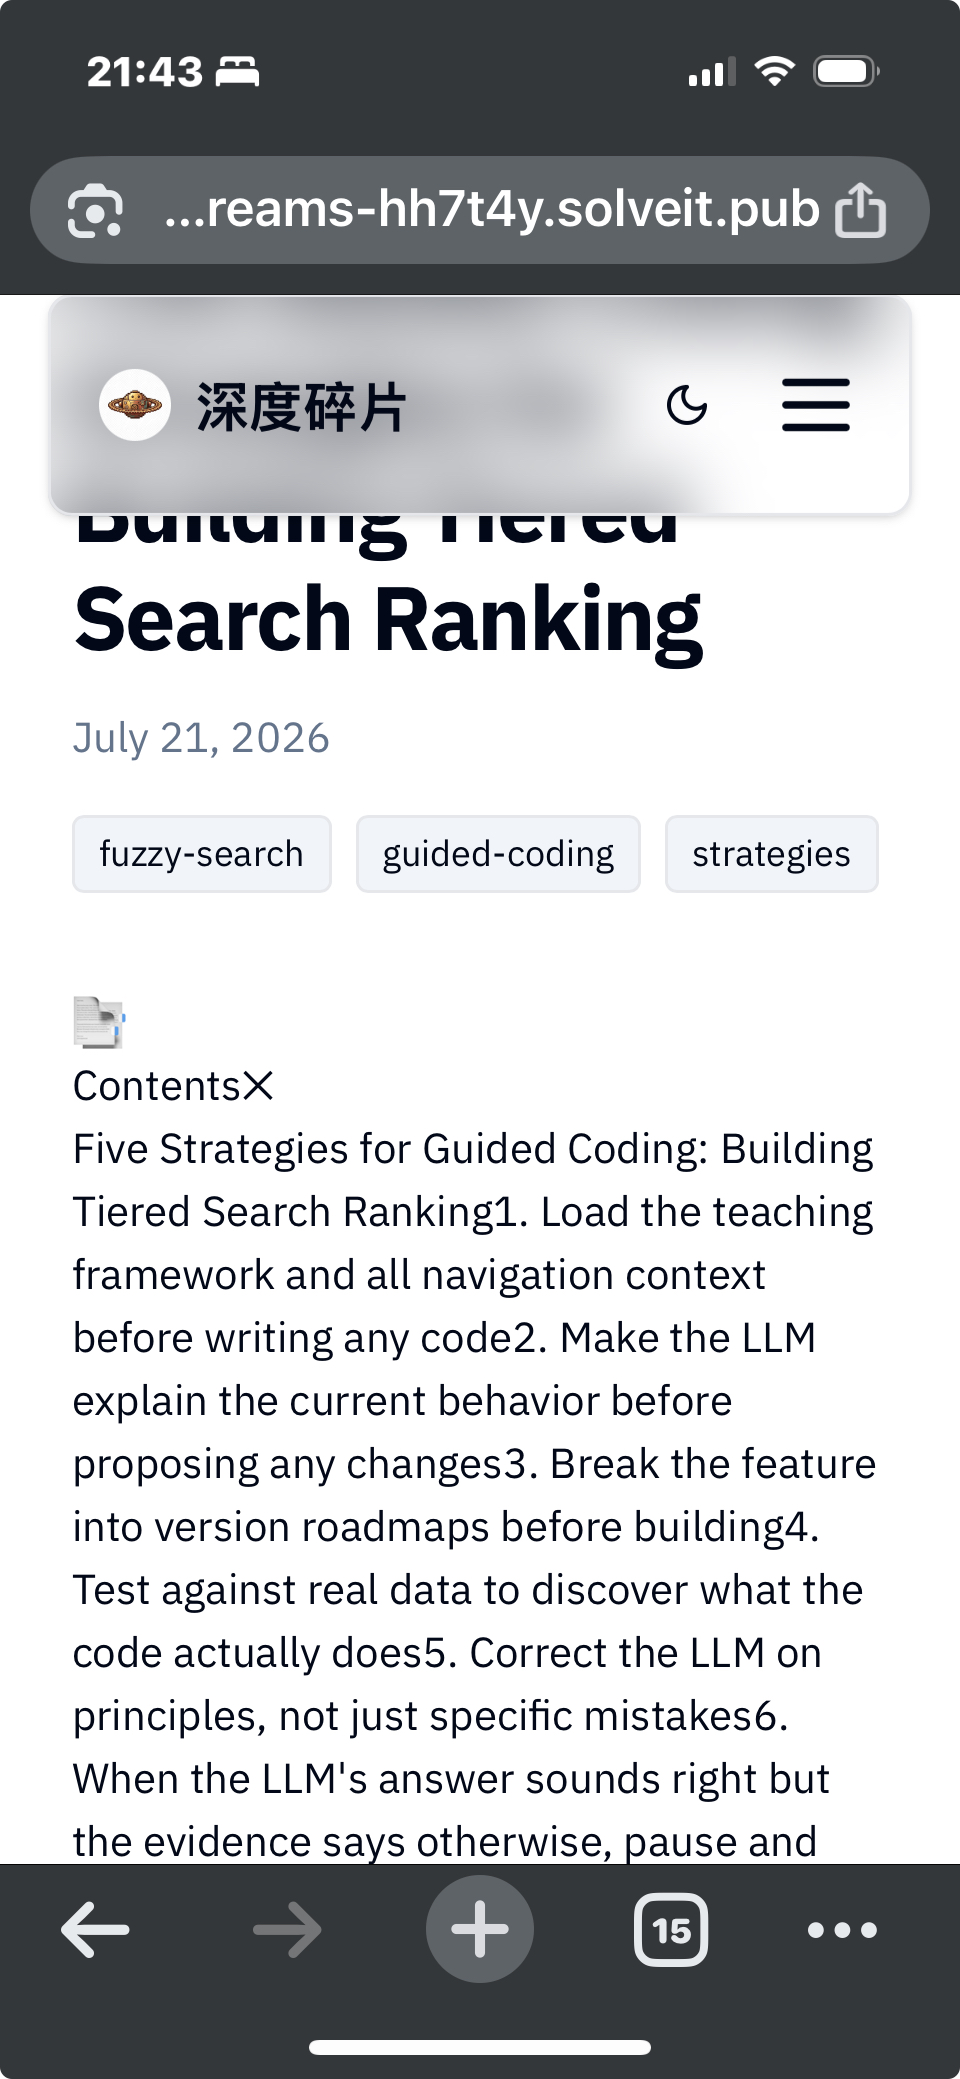

With my custom.css
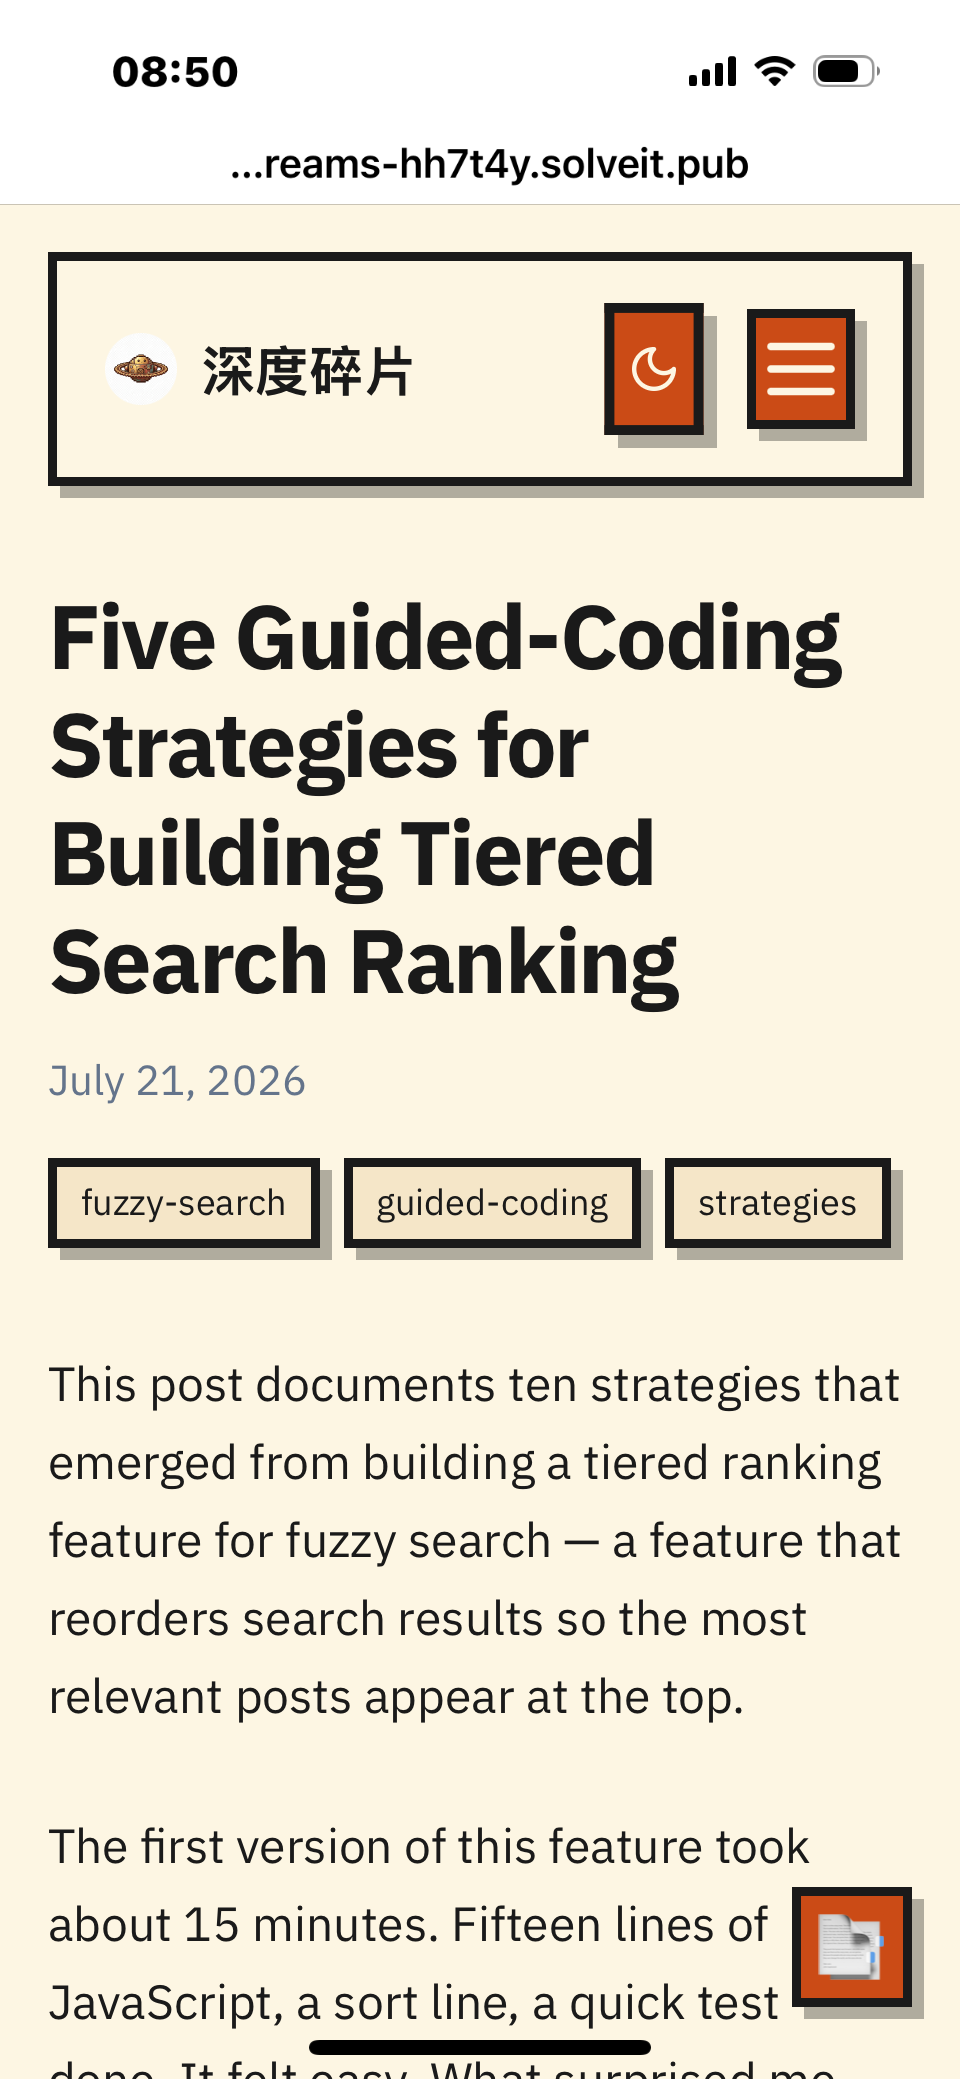

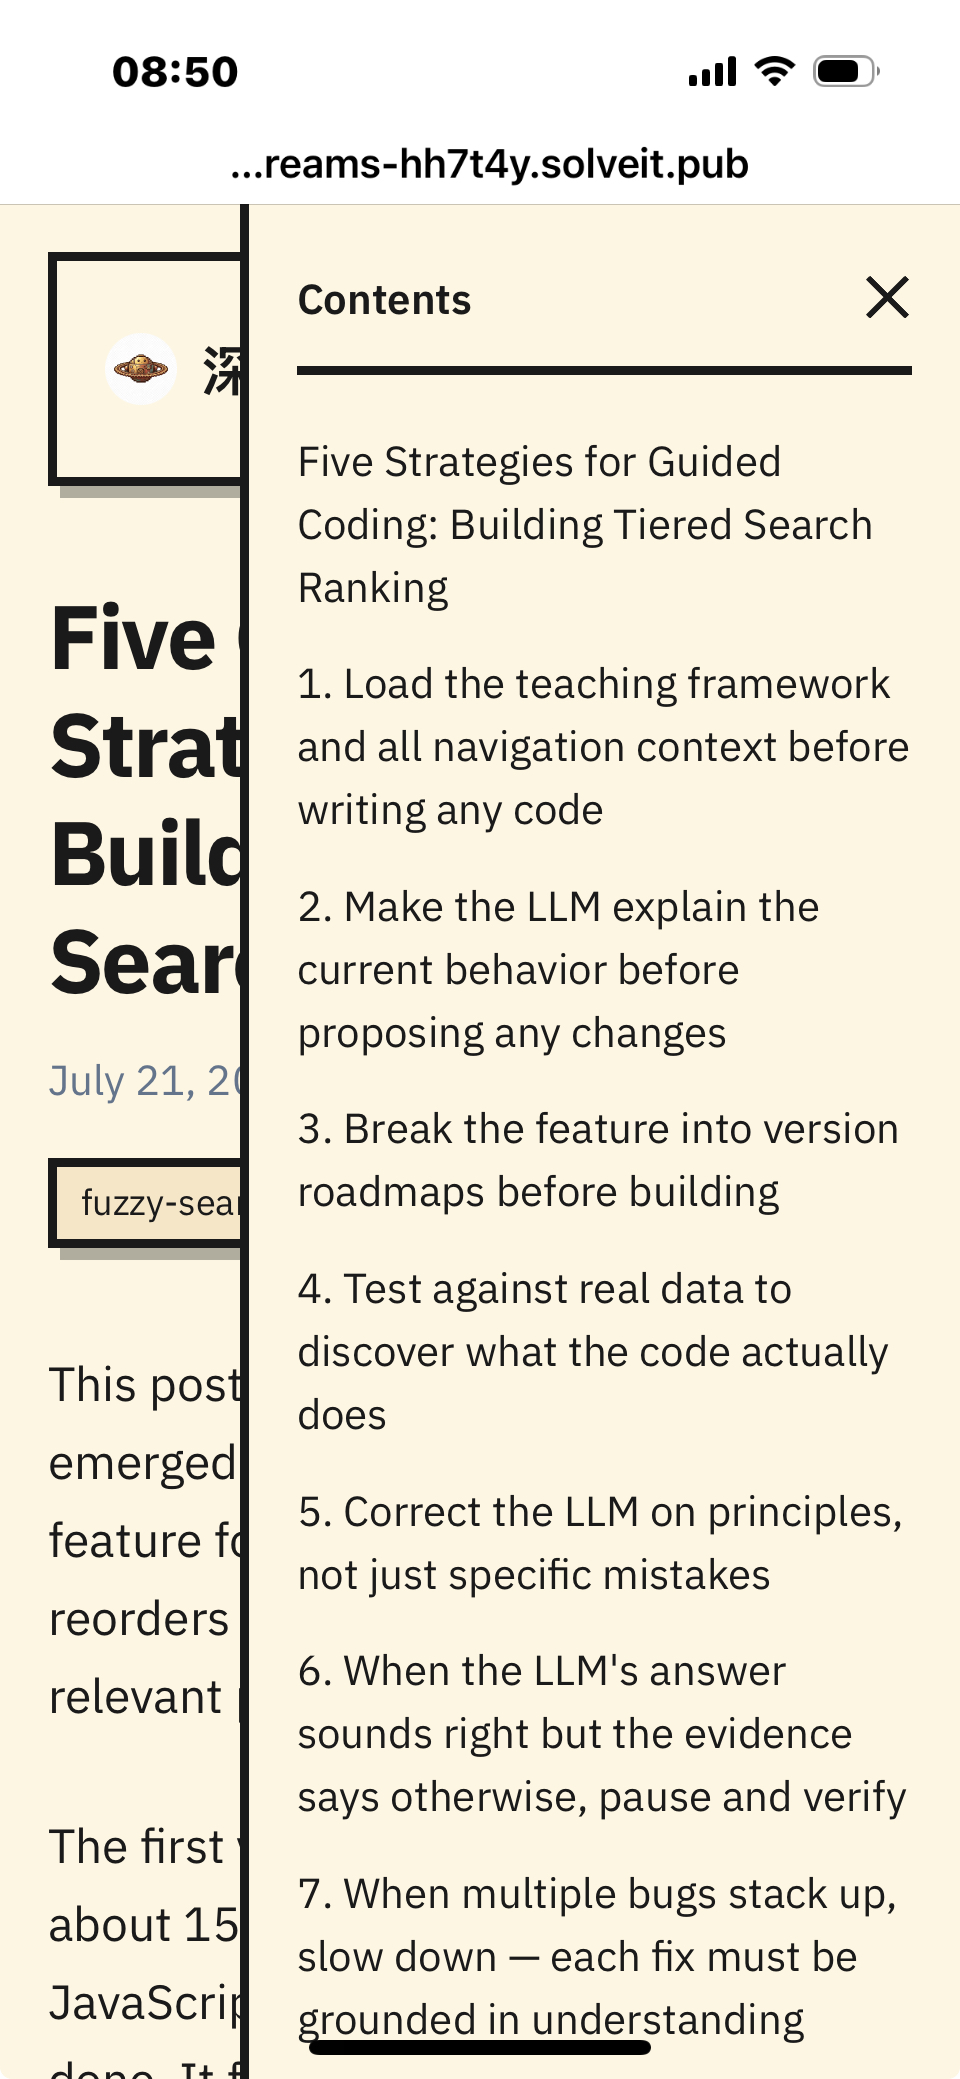
